# What this notebook is doing (sub-basin analysis)

This notebook is where I grouped a lot of the Skagit sub-basin work together.
It starts by checking which HUC8 basins actually make up most of the Skagit area, and that is what led to using Upper Skagit, Sauk, and Lower Skagit as the main 3-region setup.

After that, the notebook has several different analysis sections built around those same three sub-basins.
There are sections for meteorological seasons, water year totals, event-based cumulative precipitation comparisons, and some PNNL-specific sub-basin workflows.

So this is not just one plot or one calculation.
It is more like the main working notebook for sub-basin-level precipitation analysis once the 3-region breakdown was decided.


In [1]:
import geopandas as gpd
import pandas as pd

SKAGIT_BOUNDARY = "../data/GIS/SkagitBoundary.json"
HUC8_FILE       = "../data/GIS/SkagitSubBasin_HUC8.geojson"

# -------------------------
# Load
# -------------------------
skagit = gpd.read_file(SKAGIT_BOUNDARY)
huc8   = gpd.read_file(HUC8_FILE)

# Ensure same CRS
if huc8.crs != skagit.crs:
    huc8 = huc8.to_crs(skagit.crs)

# Basic cleanup (optional but often helps)
skagit["geometry"] = skagit.geometry.buffer(0)
huc8["geometry"]   = huc8.geometry.buffer(0)

# -------------------------
# 1) HUC8s that INTERSECT Skagit
# -------------------------
skagit_geom = skagit.geometry.iloc[0]
huc8_int = huc8[huc8.intersects(skagit_geom)].copy()

print("Intersecting HUC8 count:", len(huc8_int))
print(huc8_int[["HUC8", "Name"]].sort_values(["Name"]))

# -------------------------
# 2) Clip intersecting HUC8s to Skagit and compute area contribution
#    Use an equal-area projection for area math
# -------------------------
# Intersection geometry: "how much of each HUC8 is inside Skagit"
huc8_clip = gpd.overlay(huc8_int, skagit, how="intersection")

# Project to equal-area CRS (good for WA + CONUS)
huc8_clip = huc8_clip.to_crs(5070)  # NAD83 / Conus Albers
skagit_ea = skagit.to_crs(5070)

# Areas
huc8_clip["area_km2_in_skagit"] = huc8_clip.area / 1e6
skagit_area_km2 = skagit_ea.geometry.iloc[0].area / 1e6

# Aggregate in case a HUC8 becomes multiple pieces after overlay
summary = (
    huc8_clip.groupby(["HUC8", "Name"], as_index=False)["area_km2_in_skagit"]
    .sum()
)

summary["pct_of_skagit"] = 100.0 * summary["area_km2_in_skagit"] / skagit_area_km2
summary = summary.sort_values("area_km2_in_skagit", ascending=False)

print("\nSkagit total area (km^2):", skagit_area_km2)
print("\nHUC8 contribution inside Skagit (sorted):")
print(summary.to_string(index=False))

# -------------------------
# 3) Show "top 3" dominant regions
# -------------------------
top3 = summary.head(3).copy()
print("\nTop 3 HUC8s by area inside Skagit:")
print(top3.to_string(index=False))

print("\nTop 3 combined % of Skagit:",
      round(top3["pct_of_skagit"].sum(), 2), "%")

# Optional: keep only meaningful contributors (e.g., >= 1% of Skagit)
meaningful = summary[summary["pct_of_skagit"] >= 1.0]
print("\nMeaningful HUC8s (>=1% of Skagit):")
print(meaningful.to_string(index=False))


Intersecting HUC8 count: 12
        HUC8               Name
43  17020009        Lake Chelan
66  17110007       Lower Skagit
42  17020008             Methow
64  17110004           Nooksack
65  17110006               Sauk
54  17020007        Similkameen
61  17110009          Skykomish
67  17110008      Stillaguamish
6   17110002  Strait of Georgia
62  17110001        Sumas River
29  17110005       Upper Skagit
9   17020011          Wenatchee

Skagit total area (km^2): 8063.292878819472

HUC8 contribution inside Skagit (sorted):
    HUC8              Name  area_km2_in_skagit  pct_of_skagit
17110005      Upper Skagit         5194.472322      64.421228
17110006              Sauk         1887.870911      23.413151
17110007      Lower Skagit          931.983841      11.558353
17020007       Similkameen            7.327477       0.090875
17110008     Stillaguamish            5.908285       0.073274
17020009       Lake Chelan            5.044786       0.062565
17110002 Strait of Georgia        

# Seasonal

[HRRR] months available: 2014-12 … 2024-12 (n=121)
[HRRR] DJF 2014: missing months ['2013-12', '2014-01', '2014-02'] -> skipping
[HRRR] DJF 2015: Upper Skagit=541.8, Sauk=570.5, Lower Skagit=525.0
[HRRR] DJF 2016: Upper Skagit=788.4, Sauk=831.9, Lower Skagit=770.3
[HRRR] DJF 2017: Upper Skagit=443.4, Sauk=540.0, Lower Skagit=494.4
[HRRR] DJF 2018: Upper Skagit=668.4, Sauk=828.6, Lower Skagit=783.4
[HRRR] DJF 2019: Upper Skagit=692.5, Sauk=739.1, Lower Skagit=582.3
[HRRR] DJF 2020: Upper Skagit=869.6, Sauk=1134.5, Lower Skagit=890.5
[HRRR] DJF 2021: Upper Skagit=740.4, Sauk=961.2, Lower Skagit=726.0
[HRRR] DJF 2022: Upper Skagit=555.9, Sauk=763.5, Lower Skagit=597.2
[HRRR] DJF 2023: Upper Skagit=506.8, Sauk=638.9, Lower Skagit=566.1
[HRRR] DJF 2024: Upper Skagit=352.0, Sauk=474.3, Lower Skagit=402.1
[HRRR] MAM 2014: missing months ['2014-03', '2014-04', '2014-05'] -> skipping
[HRRR] MAM 2015: Upper Skagit=246.9, Sauk=260.9, Lower Skagit=239.1
[HRRR] MAM 2016: Upper Skagit=265.7, Sauk=33

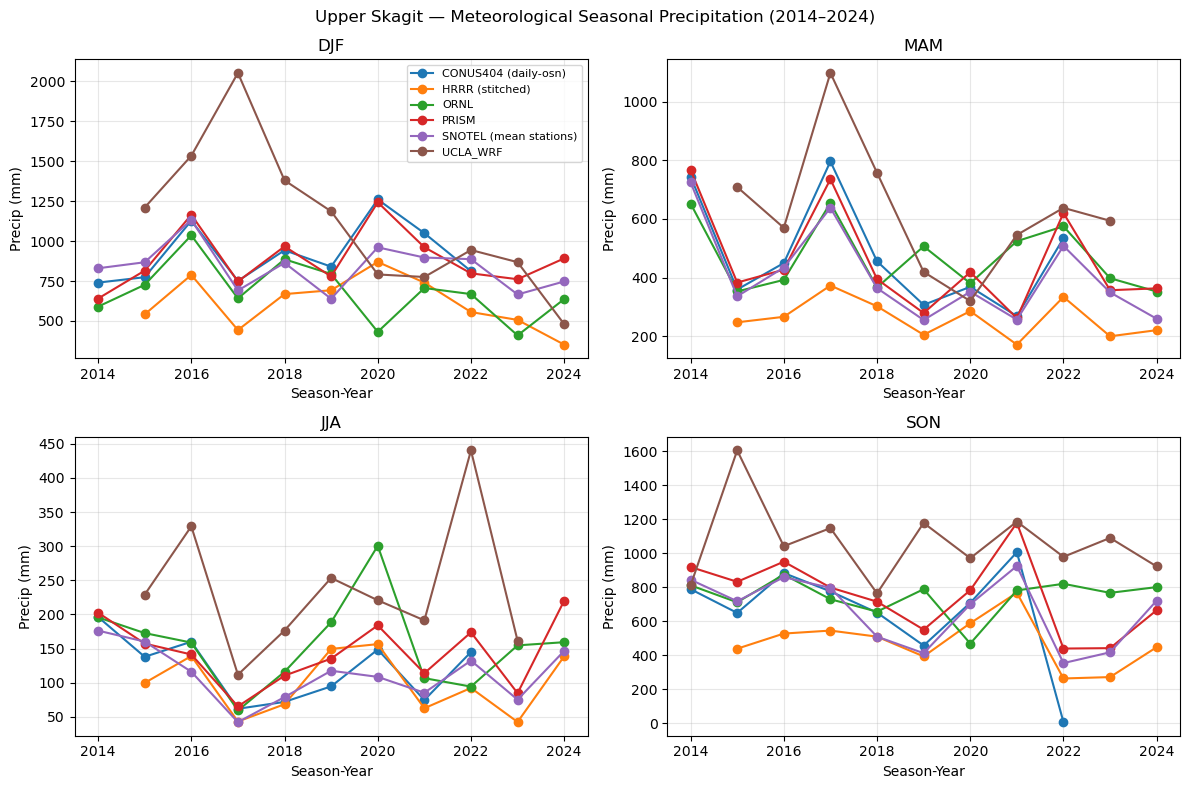

Saved plot → /data0/balaji24/data/derived/met_season_precip_Sauk_2014_2024.png


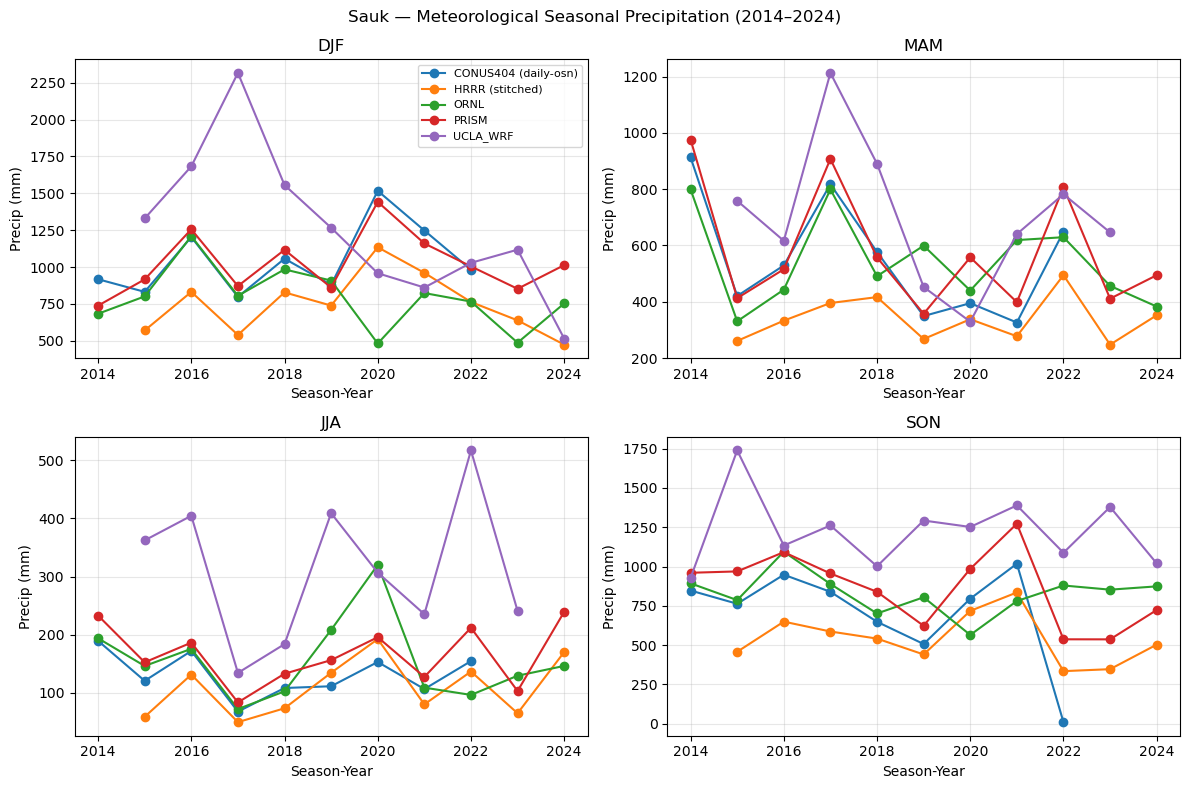

Saved plot → /data0/balaji24/data/derived/met_season_precip_Lower_Skagit_2014_2024.png


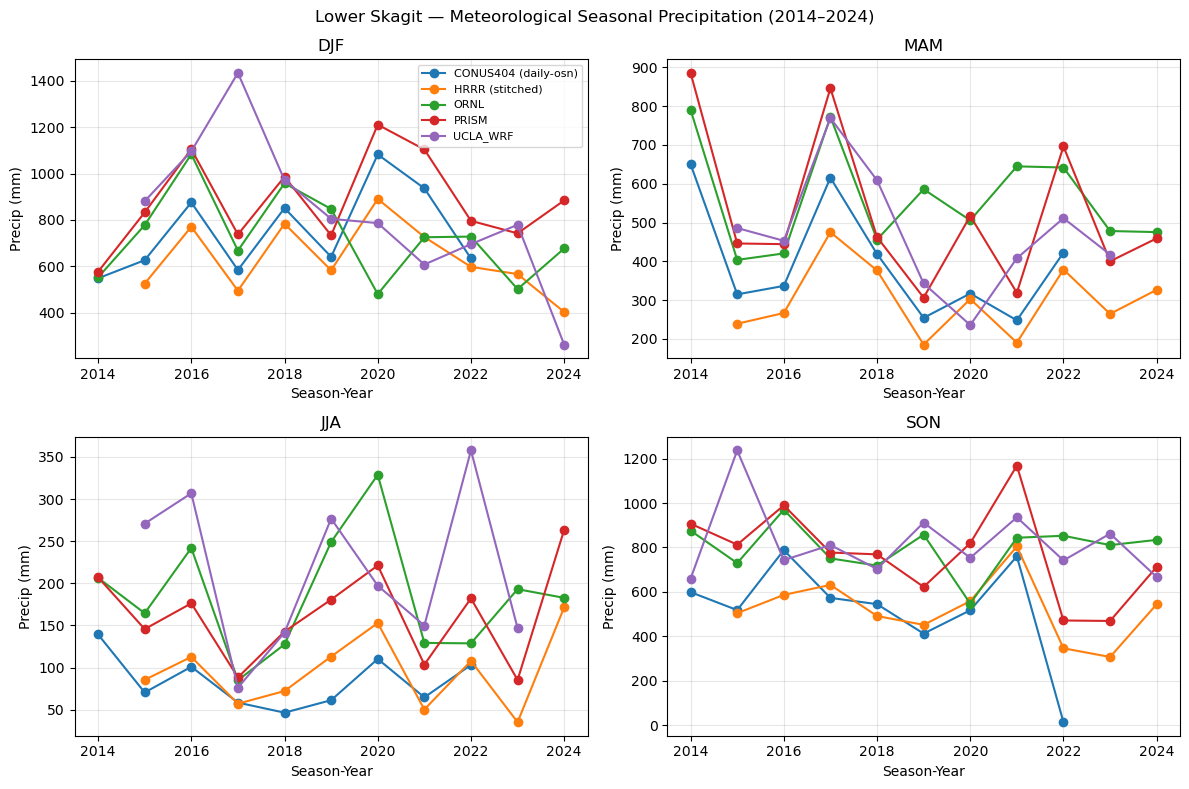

Saved summary plot → /data0/balaji24/data/derived/met_season_precip_skagit_regions_2014_2024_ALL.png


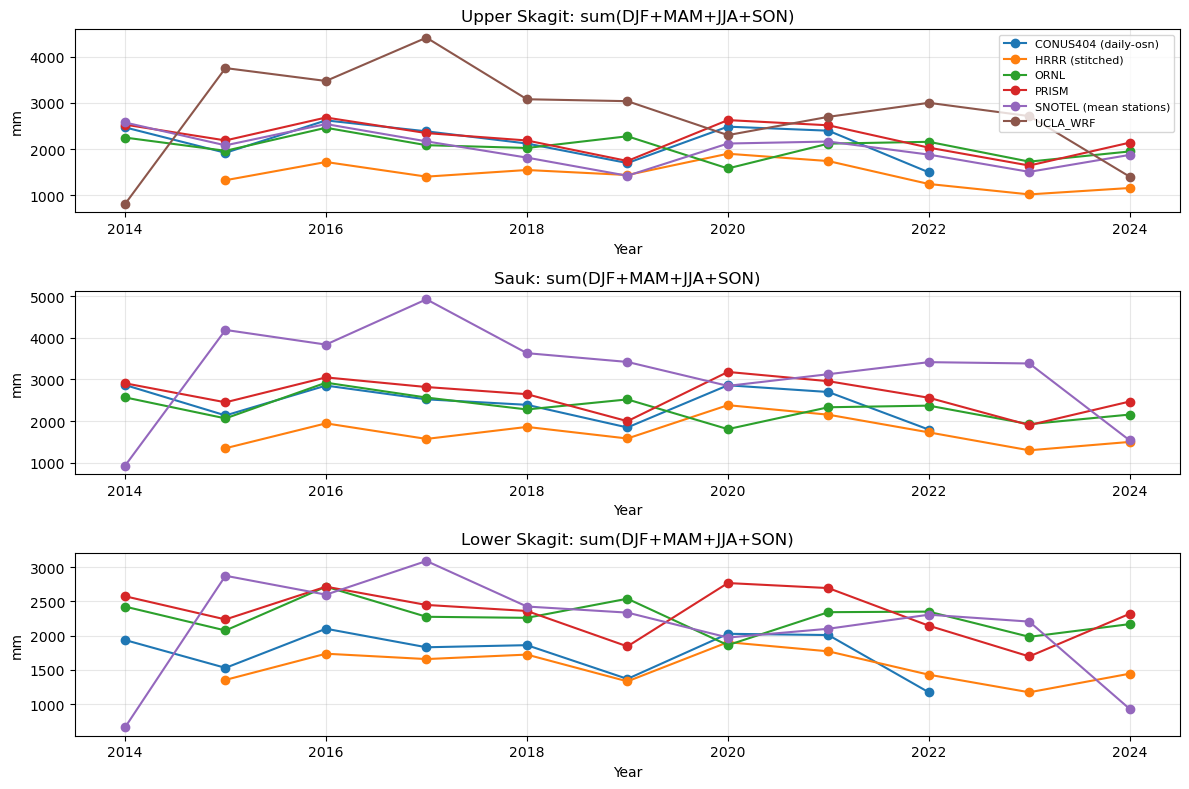


[MAE vs PRISM] Per (region, season, year) (mm):
           region season  year                 dataset      mae_mm
0    Lower Skagit    DJF  2014    CONUS404 (daily-osn)   28.165770
1    Lower Skagit    DJF  2014         HRRR (stitched)         NaN
2    Lower Skagit    DJF  2014                    ORNL   24.248724
3    Lower Skagit    DJF  2014  SNOTEL (mean stations)         NaN
4    Lower Skagit    DJF  2014                UCLA_WRF         NaN
..            ...    ...   ...                     ...         ...
655  Upper Skagit    SON  2024    CONUS404 (daily-osn)         NaN
656  Upper Skagit    SON  2024         HRRR (stitched)  217.481896
657  Upper Skagit    SON  2024                    ORNL  135.705257
658  Upper Skagit    SON  2024  SNOTEL (mean stations)   56.636730
659  Upper Skagit    SON  2024                UCLA_WRF  257.053909

[660 rows x 5 columns]
Saved MAE CSV → /data0/balaji24/data/derived/met_season_mae_vs_PRISM_skagit_regions_2014_2024.csv
Saved MAE plot → /data0/b

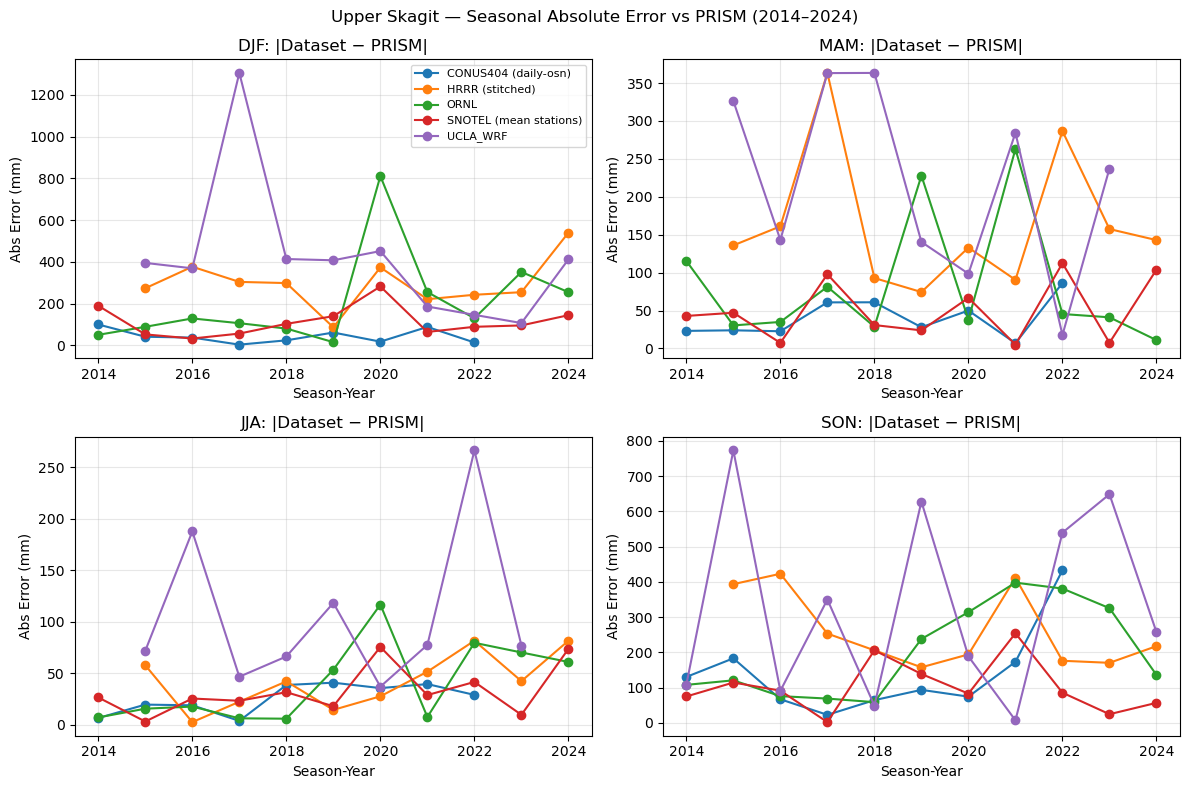

Saved MAE plot → /data0/balaji24/data/derived/met_season_mae_vs_PRISM_Sauk_2014_2024.png


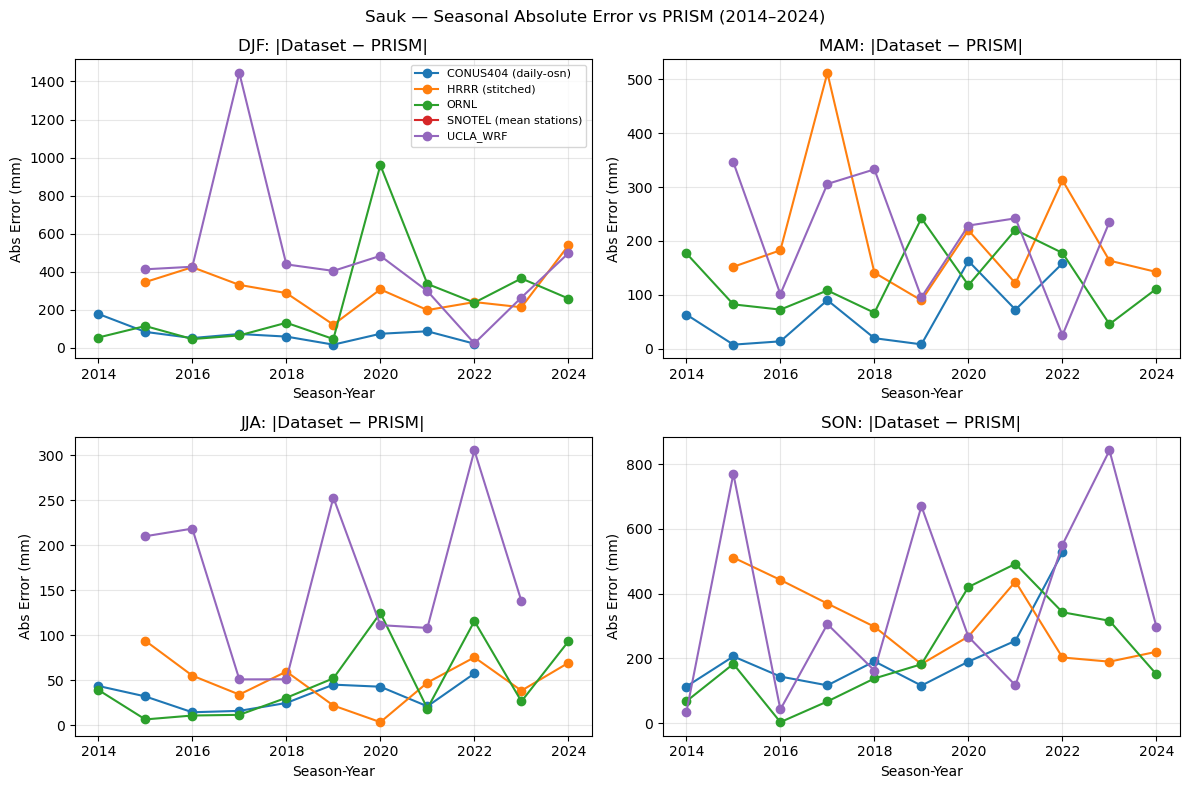

Saved MAE plot → /data0/balaji24/data/derived/met_season_mae_vs_PRISM_Lower_Skagit_2014_2024.png


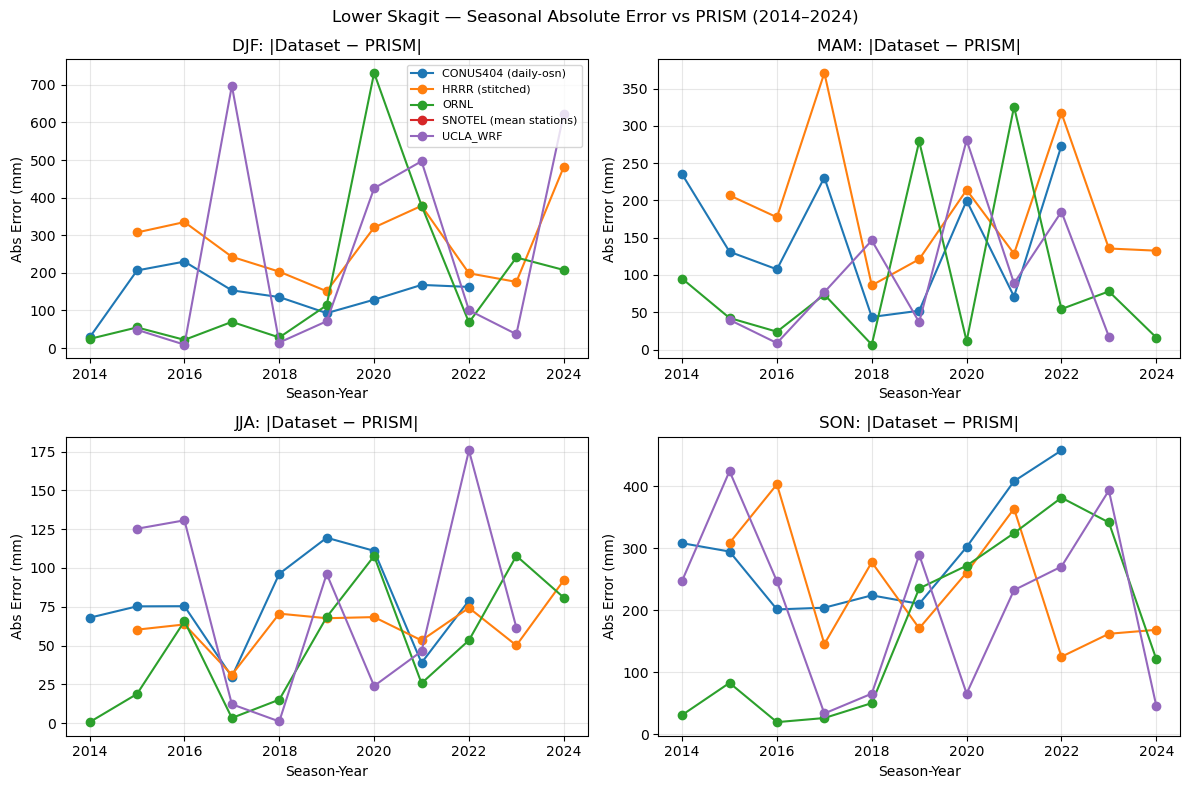

Saved MAE summary plot → /data0/balaji24/data/derived/met_season_mae_vs_PRISM_skagit_regions_2014_2024.png


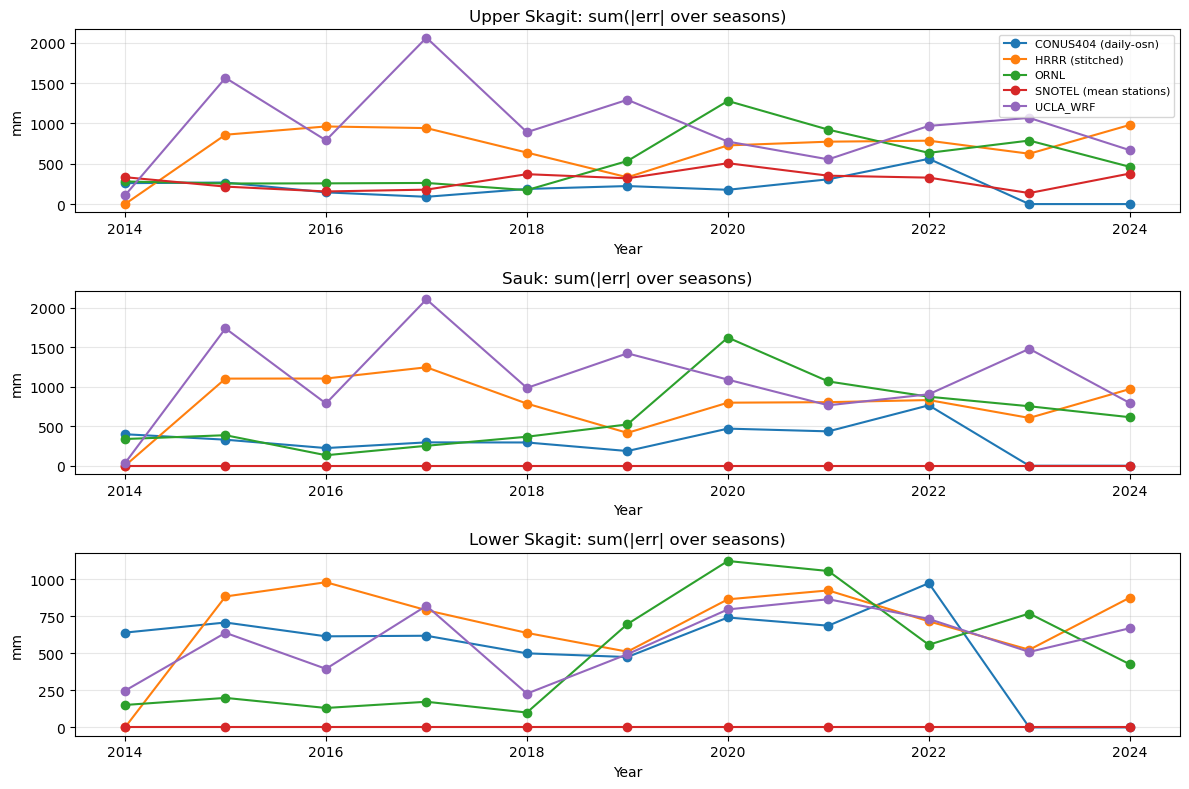

In [ ]:
# ============================
# Skagit Basin — METEOROLOGICAL SEASON Precip (mm) by dataset (DJF/MAM/JJA/SON)
# NOW BY 3 REGIONS (HUC8-dominant sub-basins):
#   - Upper Skagit
#   - Sauk
#   - Lower Skagit
#
# Safe, de-accumulating where needed, robust to duplicates
#
# METEOROLOGICAL SEASONS:
#   - DJF = Dec(previous year) + Jan/Feb(current year)  -> labeled by ending year
#   - MAM = Mar/Apr/May (year)
#   - JJA = Jun/Jul/Aug (year)
#   - SON = Sep/Oct/Nov (year)
#
# ADD:
# - Per-(region,season,year) absolute error (|err|) vs PRISM for all other datasets
# ============================

import json, re
from pathlib import Path
from glob import glob
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# ---------------- Config ----------------
BASE = Path("/data0/balaji24/data")
BOUNDARY_GEO = Path("../data/GIS/SkagitBoundary.json")
HUC8_GEO     = Path("../data/GIS/SkagitSubBasin_HUC8.geojson")

YEAR_MIN, YEAR_MAX = 2014, 2024   # season-year labels (DJF labeled by ending year)

# dataset roots
P_ORNL_DIR   = BASE / "ornl"
P_PRISM_DIR  = BASE / "prism_ppt"
P_HRRR_DIR   = BASE / "weather_data"             # many YYYY-MM_HRRR_data.zarr
P_WRF_DIR    = BASE / "ucla_wrf_outputs"         # yearly zarrs
PNNL_HIST    = BASE / "PNNL" / "historical"      # hourly NetCDFs per year

OUT = BASE / "derived"
OUT.mkdir(parents=True, exist_ok=True)

# outputs
CSV_OUT = OUT / f"met_season_precip_skagit_regions_{YEAR_MIN}_{YEAR_MAX}_ALL.csv"
PNG_OUT = OUT / f"met_season_precip_skagit_regions_{YEAR_MIN}_{YEAR_MAX}_ALL.png"

MAE_REF = "PRISM"
MAE_CSV_OUT = OUT / f"met_season_mae_vs_{MAE_REF}_skagit_regions_{YEAR_MIN}_{YEAR_MAX}.csv"
MAE_PNG_OUT = OUT / f"met_season_mae_vs_{MAE_REF}_skagit_regions_{YEAR_MIN}_{YEAR_MAX}.png"

# 3-region definition (dominant HUC8s inside Skagit)
REGION_NAMES = ["Upper Skagit", "Sauk", "Lower Skagit"]

# ---------------- Helpers ----------------
def safe_open_zarr(p: Path):
    try:
        return xr.open_zarr(p, consolidated=True)
    except Exception:
        return xr.open_zarr(p, consolidated=False)

def find_lat_lon_names(ds):
    lat_name = next((n for n in ["lat","latitude","XLAT","XLAT_M"] if n in ds), None)
    lon_name = next((n for n in ["lon","longitude","XLONG","XLONG_M"] if n in ds), None)
    return lat_name, lon_name

def ensure_time_sorted_unique(da):
    if "time" not in da.dims:
        return da
    da = da.sortby("time")
    try:
        t = xr.DataArray(da["time"].values)
        _, idx = np.unique(t.values, return_index=True)
        da = da.isel(time=np.sort(idx))
    except Exception:
        pass
    return da

def to_incremental_mm(da, force_cumulative=False):
    """Normalize precip to incremental per-step in mm; deaccumulate if cumulative."""
    units = str(da.attrs.get("units", "")).lower()
    name  = (da.name or "").lower()

    if units.strip() in {"m", "meter", "meters"}:
        da = da * 1000.0
        da.attrs["units"] = "mm"

    if "kg m" in units and "-2" in units:
        da.attrs["units"] = "mm"

    is_cum = (
        force_cumulative
        or any(k in name for k in ["prec_acc_nc", "rainnc", "rainc", "acc"])
        or ("cumulative" in units)
    )

    da = ensure_time_sorted_unique(da)

    if is_cum:
        inc = da.diff("time", label="upper")
        inc = inc.where(inc >= 0, 0)  # clip resets
        inc = xr.concat([da.isel(time=slice(0, 1)) * 0, inc], dim="time")
        inc.attrs["units"] = "mm"
        return inc

    return da

# ---------------- Region handling ----------------
def load_regions_gdf():
    """Load the 3 dominant HUC8 polygons, clipped to Skagit boundary."""
    import geopandas as gpd

    skagit_gdf = gpd.read_file(BOUNDARY_GEO).to_crs("EPSG:4326")
    huc8 = gpd.read_file(HUC8_GEO).to_crs("EPSG:4326")

    huc8_3 = huc8[huc8["Name"].isin(REGION_NAMES)].copy()
    if huc8_3.empty:
        raise ValueError(
            f"No matching HUC8 regions found for {REGION_NAMES}. "
            f"Check HUC8_GEO path and the 'Name' field values."
        )

    # clip each HUC8 polygon to Skagit boundary (ensures no outside slivers)
    huc8_3 = gpd.overlay(huc8_3, skagit_gdf, how="intersection")
    regions_gdf = huc8_3[["Name", "geometry"]].reset_index(drop=True)

    # preserve desired order
    regions_gdf["Name"] = pd.Categorical(regions_gdf["Name"], categories=REGION_NAMES, ordered=True)
    regions_gdf = regions_gdf.sort_values("Name").reset_index(drop=True)
    return regions_gdf

def _to_2d(arr):
    """Take a lat/lon-like array and reduce it to 2D (y,x) or (lat,lon)."""
    if "time" in arr.dims:
        arr = arr.isel(time=0)
    for d in list(arr.dims):
        if arr.sizes[d] == 1:
            arr = arr.isel({d: 0})
    while arr.ndim > 2:
        extra = [d for d in arr.dims if d not in ("x","y","lon","lat")]
        if not extra:
            break
        arr = arr.isel({extra[0]: 0})
    return arr

def region_mean(da, grid_ds=None, regions_gdf=None):
    """
    Mean(da) inside each region polygon.
    Returns DataArray with an added 'region' dimension.
    """
    if regions_gdf is None:
        raise ValueError("regions_gdf is required for region_mean")

    try:
        import regionmask
    except Exception as e:
        raise RuntimeError(f"regionmask is required for region_mean: {e}")

    time_dim = "time" if "time" in da.dims else None
    spatial = [d for d in da.dims if d != time_dim]
    if not spatial:
        # degenerate case: no spatial dims
        out = da
        return out.expand_dims(region=list(regions_gdf["Name"].values))

    host = grid_ds if grid_ds is not None else da.to_dataset(name="_tmp")
    lat_name, lon_name = find_lat_lon_names(host)
    if not (lat_name and lon_name):
        # fallback: simple spatial mean (no masking possible)
        out = da.mean(spatial, skipna=True)
        return out.expand_dims(region=list(regions_gdf["Name"].values))

    lon = _to_2d(host[lon_name])
    lat = _to_2d(host[lat_name])

    regs = regionmask.Regions(
        outlines=list(regions_gdf.geometry.values),
        names=list(regions_gdf["Name"].astype(str).values),
        numbers=list(range(len(regions_gdf))),
        name="Skagit_3HUC8",
    )

    rid = regs.mask(lon, lat)

    out_list = []
    for i, rname in enumerate(regs.names):
        m = (rid == i)
        w = xr.where(m, 1.0, np.nan)
        out_list.append((da * w).mean(spatial, skipna=True))

    out = xr.concat(out_list, dim="region")
    out = out.assign_coords(region=regs.names)
    return out

# ---------------- MET SEASON helpers ----------------
SEASONS = {
    "DJF": [12, 1, 2],
    "MAM": [3, 4, 5],
    "JJA": [6, 7, 8],
    "SON": [9, 10, 11],
}

def season_year_index(time_da, season_label):
    """DJF labeled by ending year (Dec -> y+1). Others labeled by calendar year."""
    y = time_da.dt.year
    m = time_da.dt.month
    if season_label == "DJF":
        return xr.where(m == 12, y + 1, y)
    return y

def seasonal_sum_mm(da, season_label):
    """
    Sum over a meteorological season grouped by season-year.
    Works for da with dims like ('time', 'region') or ('time',).
    """
    if "time" not in da.dims:
        return None
    da = ensure_time_sorted_unique(da)
    months = SEASONS[season_label]
    da_s = da.where(da["time"].dt.month.isin(months), drop=True)
    if da_s.sizes.get("time", 0) == 0:
        return None
    sy = season_year_index(da_s["time"], season_label)
    out = da_s.groupby(sy).sum("time", skipna=True)
    out = out.rename({"group": "year"}) if "group" in out.dims else out
    out.name = "mm"
    return out

def pick_year(ann, year):
    """(Legacy helper) kept for compatibility with previous style."""
    if ann is None:
        return np.nan
    try:
        if "year" in ann.coords:
            return float(ann.sel(year=year).values)
        for c in ann.coords:
            if "year" in str(c):
                return float(ann.sel({c: year}).values)
        return float(ann.values.item())
    except Exception:
        return np.nan

def season_time_window(year, season_label):
    """Return ISO start/end strings (inclusive slice) for season-year."""
    def month_end(y, m):
        return (pd.Timestamp(y, m, 1) + pd.offsets.MonthEnd(0)).strftime("%Y-%m-%d")

    if season_label == "DJF":
        start = pd.Timestamp(year - 1, 12, 1).strftime("%Y-%m-%d")
        end   = month_end(year, 2)
        return start, end
    if season_label == "MAM":
        return f"{year}-03-01", month_end(year, 5)
    if season_label == "JJA":
        return f"{year}-06-01", month_end(year, 8)
    if season_label == "SON":
        return f"{year}-09-01", month_end(year, 11)
    raise ValueError(season_label)

# --------- HRRR robust deaccumulation ----------
def deaccumulate_generic(da, time_dim="time", clip_zero=True):
    run_coord = next((c for c in ("run", "init", "forecast_reference_time") if c in da.coords), None)
    step_coord = next((c for c in ("step", "lead", "forecast_hour") if c in da.coords), None)
    if run_coord and step_coord:
        dif = da.sortby([run_coord, step_coord]).diff(step_coord, label="upper")
        if clip_zero:
            dif = xr.where(dif < 0, 0, dif)
        return dif.fillna(0)

    da = da.sortby(time_dim)
    dif = da.diff(time_dim, label="upper")
    if clip_zero:
        dif = xr.where(dif < 0, 0, dif)
    return dif.fillna(0)

def hrrr_hourly_precip_mm(ds, var="tp"):
    da = ds[var]
    probe = da.isel({k: 0 for k in da.dims if k not in ("time", "step")})
    vals = probe.values
    is_cum = False
    if getattr(vals, "ndim", 0) == 1 and vals.size > 6:
        dif = np.diff(vals[:200] if vals.size > 200 else vals)
        is_cum = (dif >= -1e-6).mean() > 0.9
    return deaccumulate_generic(da, time_dim="time", clip_zero=True) if is_cum else da

def hrrr_month_prefixes_for_season_year(year: int, season_label: str):
    if season_label == "DJF":
        return {f"{year-1}-12", f"{year}-01", f"{year}-02"}
    if season_label == "MAM":
        return {f"{year}-03", f"{year}-04", f"{year}-05"}
    if season_label == "JJA":
        return {f"{year}-06", f"{year}-07", f"{year}-08"}
    if season_label == "SON":
        return {f"{year}-09", f"{year}-10", f"{year}-11"}
    raise ValueError(season_label)

# ---------------- Collectors ----------------
regions_gdf = load_regions_gdf()
rows = []

GLOBAL_START = f"{YEAR_MIN-1}-12-01"
GLOBAL_END   = (pd.Timestamp(YEAR_MAX, 11, 1) + pd.offsets.MonthEnd(0)).strftime("%Y-%m-%d")

# ---------- ORNL ----------
if P_ORNL_DIR.exists():
    ornl_years = sorted(P_ORNL_DIR.glob("*_ORNL_data.zarr"))
    if ornl_years:
        dso = xr.concat(
            [safe_open_zarr(p) for p in ornl_years],
            dim="time", join="outer", coords="minimal", compat="override"
        )
        if "prcp" in dso:
            da = ensure_time_sorted_unique(dso["prcp"])
            rm = region_mean(da, grid_ds=dso, regions_gdf=regions_gdf).sel(time=slice(GLOBAL_START, GLOBAL_END))

            for s in SEASONS.keys():
                ann = seasonal_sum_mm(rm, s)  # dims: (year, region)
                if ann is None:
                    continue
                for yr in range(YEAR_MIN, YEAR_MAX + 1):
                    for rname in ann["region"].values:
                        try:
                            val = float(ann.sel(year=yr, region=rname).values)
                        except Exception:
                            val = np.nan
                        if not np.isnan(val):
                            rows.append({"dataset": "ORNL", "region": str(rname), "season": s, "year": yr, "mm": val})

# ---------- PRISM ----------
if P_PRISM_DIR.exists():
    prism_years = sorted(P_PRISM_DIR.glob("**/*_daily_4km_PRISM_data.zarr"))
    if prism_years:
        dsp = xr.concat(
            [safe_open_zarr(p) for p in prism_years],
            dim="time", join="outer", coords="minimal", compat="override"
        )
        v = next((v for v in ["ppt", "precip", "prcp"] if v in dsp), None)
        if v:
            da = ensure_time_sorted_unique(dsp[v])
            rm = region_mean(da, grid_ds=dsp, regions_gdf=regions_gdf).sel(time=slice(GLOBAL_START, GLOBAL_END))

            for s in SEASONS.keys():
                ann = seasonal_sum_mm(rm, s)  # dims: (year, region)
                if ann is None:
                    continue
                for yr in range(YEAR_MIN, YEAR_MAX + 1):
                    for rname in ann["region"].values:
                        try:
                            val = float(ann.sel(year=yr, region=rname).values)
                        except Exception:
                            val = np.nan
                        if not np.isnan(val):
                            rows.append({"dataset": "PRISM", "region": str(rname), "season": s, "year": yr, "mm": val})

# ---------- HRRR ----------
hrrr_months = sorted(P_HRRR_DIR.glob("*.zarr"))
monthly = [p for p in hrrr_months if re.match(r"\d{4}-\d{2}_HRRR_data\.zarr", p.name)]
available = {p.name[:7] for p in monthly}

if monthly:
    available_prefixes = sorted(list(available))
    print(f"[HRRR] months available: {available_prefixes[0]} … {available_prefixes[-1]} (n={len(available_prefixes)})")

    for s in SEASONS.keys():
        for yr in range(YEAR_MIN, YEAR_MAX + 1):
            need = hrrr_month_prefixes_for_season_year(yr, s)
            missing = sorted(list(need - available))
            if missing:
                print(f"[HRRR] {s} {yr}: missing months {missing} -> skipping")
                continue

            parts = sorted([p for p in monthly if p.name[:7] in need], key=lambda p: p.name[:7])
            ds0 = safe_open_zarr(parts[0])

            var = "tp" if "tp" in ds0 else ("apcp" if "apcp" in ds0 else None)
            if not var:
                print(f"[HRRR] {s} {yr}: no tp/apcp in {parts[0].name} -> skipping")
                try: ds0.close()
                except Exception: pass
                continue

            dsets = []
            ok = True
            for p in parts:
                dsm = safe_open_zarr(p)
                if var not in dsm:
                    print(f"[HRRR] {s} {yr}: {p.name} missing {var} -> skipping")
                    try: dsm.close()
                    except Exception: pass
                    ok = False
                    break
                dsets.append(dsm[[var]])

            if not ok:
                for d in dsets:
                    try: d.close()
                    except Exception: pass
                try: ds0.close()
                except Exception: pass
                continue

            ds = xr.concat(dsets, dim="time", join="outer", coords="minimal", compat="override").sortby("time")

            hourly_mm = hrrr_hourly_precip_mm(ds, var=var)
            if hourly_mm.sizes.get("time", 0) == 0:
                for d in dsets:
                    try: d.close()
                    except Exception: pass
                try: ds0.close()
                except Exception: pass
                continue

            daily = hourly_mm.resample(time="1D").sum()
            rm_daily = region_mean(daily, grid_ds=ds0, regions_gdf=regions_gdf)
            rm_daily = ensure_time_sorted_unique(rm_daily)

            t0, t1 = season_time_window(yr, s)
            rm_daily = rm_daily.sel(time=slice(t0, t1))
            if rm_daily.sizes.get("time", 0) == 0:
                for d in dsets:
                    try: d.close()
                    except Exception: pass
                try: ds0.close()
                except Exception: pass
                continue

            # total per region
            season_tot = rm_daily.sum("time", skipna=True)
            for rname in season_tot["region"].values:
                val = float(season_tot.sel(region=rname).values)
                rows.append({"dataset": "HRRR (stitched)", "region": str(rname), "season": s, "year": yr, "mm": val})

            print(f"[HRRR] {s} {yr}: " + ", ".join([f"{r}={float(season_tot.sel(region=r)):.1f}" for r in season_tot["region"].values]))

            for d in dsets:
                try: d.close()
                except Exception: pass
            try: ds0.close()
            except Exception: pass
else:
    print("[HRRR] No HRRR monthly zarrs found -> skipping HRRR.")

# ---------- UCLA WRF ----------
if P_WRF_DIR.exists():
    wrf_zarrs = sorted(P_WRF_DIR.glob("*.zarr"))
    year_to_zarr = {}
    for z in wrf_zarrs:
        m = re.search(r"(\d{4})", z.name)
        if m:
            year_to_zarr[int(m.group(1))] = z

    for s in SEASONS.keys():
        for yr in range(YEAR_MIN, YEAR_MAX + 1):
            need_years = {yr}
            if s == "DJF":
                need_years.add(yr - 1)

            missing_years = [y for y in sorted(need_years) if y not in year_to_zarr]
            if missing_years:
                print(f"[UCLA_WRF] {s} {yr}: missing years {missing_years} -> skipping")
                continue

            dsets = [safe_open_zarr(year_to_zarr[y]) for y in sorted(need_years)]
            dsw = xr.concat(dsets, dim="time", join="outer", coords="minimal", compat="override").sortby("time")

            v_nc = next((n for n in ["RAINNC", "rainnc"] if n in dsw), None)
            v_c  = next((n for n in ["RAINC", "rainc"] if n in dsw), None)
            if not (v_nc or v_c):
                print(f"[UCLA_WRF] {s} {yr}: no RAINNC/RAINC -> skipping")
                for d in dsets:
                    try: d.close()
                    except Exception: pass
                continue

            total = None
            for vv in [v_nc, v_c]:
                if vv:
                    inc = to_incremental_mm(dsw[vv], force_cumulative=True)
                    total = inc if total is None else total + inc

            total = ensure_time_sorted_unique(total)
            t0, t1 = season_time_window(yr, s)
            total = total.sel(time=slice(t0, t1))
            if total.sizes.get("time", 0) == 0:
                for d in dsets:
                    try: d.close()
                    except Exception: pass
                continue

            daily = total.resample(time="1D").sum()
            rm_daily = region_mean(daily, grid_ds=dsw, regions_gdf=regions_gdf)
            season_tot = rm_daily.sum("time", skipna=True)

            for rname in season_tot["region"].values:
                val = float(season_tot.sel(region=rname).values)
                rows.append({"dataset": "UCLA_WRF", "region": str(rname), "season": s, "year": yr, "mm": val})

            for d in dsets:
                try: d.close()
                except Exception: pass

# ---------- SNOTEL ----------
# NOTE: Station-based data doesn't naturally partition into the 3 polygons without station->region assignment.
# Here we assign each station to the region polygon it falls within, then compute region-wise mean station precip.
try:
    import geopandas as gpd
    import shapely.geometry as sgeom
    import requests
except ImportError as e:
    print(f"[SNOTEL] Missing dependency ({e}), skipping SNOTEL.")
else:
    print("[SNOTEL] Loading stations metadata from egagli/snotel_ccss_stations...")

    stations_url = "https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/all_stations.geojson"
    try:
        r = requests.get(stations_url, timeout=30)
        r.raise_for_status()
        gj = r.json()
    except Exception as e:
        print(f"[SNOTEL] Failed to download stations GeoJSON: {e}")
        stations = None
    else:
        records, geoms = [], []
        for feat in gj.get("features", []):
            props = feat.get("properties", {})
            geom = feat.get("geometry")
            if geom is None:
                continue
            records.append(props)
            geoms.append(sgeom.shape(geom))
        stations = gpd.GeoDataFrame(records, geometry=geoms, crs="EPSG:4326") if records else None

    if stations is None or stations.empty:
        print("[SNOTEL] No stations loaded, skipping.")
    else:
        skagit_geom = gpd.read_file(BOUNDARY_GEO).to_crs("EPSG:4326").geometry.iloc[0]
        inside = stations.geometry.within(skagit_geom)
        skagit_stations = stations[inside].copy()

        desired_names = {"Beaver Pass", "Brown Top", "Marten Ridge", "Rainy Pass", "Swamp Creek", "Thunder Basin"}
        if not skagit_stations.empty and "name" in skagit_stations.columns:
            skagit_stations = skagit_stations[skagit_stations["name"].isin(desired_names)]

        if skagit_stations.empty:
            print("[SNOTEL] No Skagit stations found after filtering, skipping.")
        else:
            # Assign station -> region
            regs = regions_gdf.copy().to_crs("EPSG:4326")
            skagit_stations = skagit_stations.to_crs("EPSG:4326")

            # spatial join: which polygon contains station
            try:
                joined = gpd.sjoin(skagit_stations, regs.rename(columns={"Name":"region"}), predicate="within", how="left")
            except TypeError:
                joined = gpd.sjoin(skagit_stations, regs.rename(columns={"Name":"region"}), op="within", how="left")

            joined = joined.dropna(subset=["region"])
            if joined.empty:
                print("[SNOTEL] Stations found but none fall within the 3 regions -> skipping.")
            else:
                print("[SNOTEL] Using stations by region:")
                for region in REGION_NAMES:
                    sub = joined[joined["region"] == region]
                    if sub.empty:
                        continue
                    names = sub["name"].tolist() if "name" in sub.columns else sub["code"].tolist()
                    print(f"  - {region}: {names}")

                base_csv_url = "https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/data"
                # dict: (region, season, year) -> list of station totals
                seasonal_values = {}

                for _, row in joined.iterrows():
                    code = row.get("code")
                    name = row.get("name", code)
                    region = row["region"]
                    if pd.isna(code):
                        continue

                    csv_url = f"{base_csv_url}/{code}.csv"
                    try:
                        df_s = pd.read_csv(csv_url, index_col="datetime", parse_dates=True)
                    except Exception as e:
                        print(f"[SNOTEL] Failed to read {code} ({name}): {e}")
                        continue

                    if "PRCPSA" not in df_s.columns:
                        print(f"[SNOTEL] No PRCPSA for {code} ({name}), skipping.")
                        continue

                    precip_mm = (df_s["PRCPSA"] * 1000.0).loc[GLOBAL_START:GLOBAL_END]
                    idx = precip_mm.index

                    month = idx.month.to_numpy()
                    year_arr = idx.year.to_numpy()

                    season = np.full(len(idx), "", dtype=object)
                    season[np.isin(month, [12, 1, 2])] = "DJF"
                    season[np.isin(month, [3, 4, 5])] = "MAM"
                    season[np.isin(month, [6, 7, 8])] = "JJA"
                    season[np.isin(month, [9, 10, 11])] = "SON"

                    season_year = year_arr.copy()
                    dec_mask = (season == "DJF") & (month == 12)
                    season_year[dec_mask] = season_year[dec_mask] + 1

                    tmp = pd.DataFrame({"mm": precip_mm.values, "season": season, "year": season_year}, index=idx)
                    tmp = tmp[(tmp["year"] >= YEAR_MIN) & (tmp["year"] <= YEAR_MAX)]
                    tmp = tmp[tmp["season"].isin(SEASONS.keys())]

                    agg = tmp.groupby(["season", "year"])["mm"].sum()
                    for (ss, yy), val in agg.items():
                        seasonal_values.setdefault((region, ss, int(yy)), []).append(float(val))

                for (region, ss, yy), vals in seasonal_values.items():
                    rows.append({
                        "dataset": "SNOTEL (mean stations)",
                        "region": str(region),
                        "season": ss,
                        "year": int(yy),
                        "mm": float(np.nanmean(vals))
                    })

# ---------- PNNL ----------
# NOTE: Your existing PNNL mask is WHOLE-SKAGIT only.
# This block will SKIP unless we create a 3-region mask file first.
PNNL_REGION_MASK = Path("/home/balaji24/skagit-met/analysis/skagit_huc8_3mask_pnnl_450x450.nc")

if PNNL_HIST.exists() and PNNL_REGION_MASK.exists():
    mask_ds = xr.open_dataset(PNNL_REGION_MASK)
    # expected: mask_ds["mask"] dims ('region','y','x') boolean OR int labels
    if "mask" not in mask_ds:
        raise ValueError("[PNNL] Expected variable 'mask' in PNNL_REGION_MASK")
    if "region" not in mask_ds["mask"].dims:
        raise ValueError("[PNNL] Expected 'mask' to have a 'region' dimension")

    region_labels = [str(r) for r in mask_ds["region"].values]

    for s in SEASONS.keys():
        for yr in range(YEAR_MIN, YEAR_MAX + 1):
            years_needed = {yr}
            if s == "DJF":
                years_needed.add(yr - 1)

            files = []
            for yy in sorted(years_needed):
                files += sorted(glob(str(PNNL_HIST / f"{yy}" / "*PREC_ACC_NC*.nc")))
            if not files:
                continue

            dsp = xr.open_mfdataset(files, combine="by_coords", engine="netcdf4", parallel=False)
            v = next((vv for vv in dsp.data_vars if "PREC_ACC_NC" in vv), None)
            if v is None:
                dsp.close()
                continue

            t0, t1 = season_time_window(yr, s)
            p = ensure_time_sorted_unique(dsp[v]).sel(time=slice(t0, t1))
            if p.sizes.get("time", 0) == 0:
                dsp.close()
                continue

            P = p.sum(dim="time").values  # shape (y,x)
            for rname in region_labels:
                m = mask_ds["mask"].sel(region=rname).values.astype(bool)
                if P.shape != m.shape:
                    raise ValueError(f"[PNNL] Shape mismatch: {P.shape} vs mask {m.shape} for region {rname}")
                rows.append({
                    "dataset": "PNNL (historical)",
                    "region": rname,
                    "season": s,
                    "year": yr,
                    "mm": float(P[m].mean()),
                })
            dsp.close()
else:
    if PNNL_HIST.exists():
        print("[PNNL] Skipping regional PNNL: missing region mask file:", PNNL_REGION_MASK)

# ---------- CONUS404 ----------
# NOTE: region-wise masking is easy here because we already have lat/lon on the grid.
try:
    import intake
    import geopandas as gpd
    import shapely
except ImportError as e:
    print(f"[CONUS404] Missing dependency ({e}), skipping CONUS404.")
else:
    print("[CONUS404] Loading from HyTEST (conus404-daily-osn)...")
    url = "https://raw.githubusercontent.com/hytest-org/hytest/main/dataset_catalog/hytest_intake_catalog.yml"
    cat = intake.open_catalog(url)
    ds = cat["conus404-catalog"]["conus404-daily-osn"].to_dask()

    var = "PREC_ACC_NC"
    if var in ds.data_vars:
        precip = ds[var].sel(time=slice(GLOBAL_START, GLOBAL_END))

        # conus404 grid
        lat = ds["lat"]
        lon = ds["lon"]

        # build per-region masks (vectorized)
        regs = regions_gdf.to_crs("EPSG:4326")

        for region in REGION_NAMES:
            geom = regs.loc[regs["Name"] == region, "geometry"].iloc[0]
            mask_np = shapely.contains_xy(geom, lon.values, lat.values)
            mask_da = xr.DataArray(mask_np, dims=("y", "x"))

            region_daily = precip.where(mask_da).mean(dim=("y", "x"))

            for s in SEASONS.keys():
                ann = seasonal_sum_mm(region_daily, s)
                for yr in range(YEAR_MIN, YEAR_MAX + 1):
                    val = pick_year(ann, yr)
                    if not np.isnan(val):
                        rows.append({
                            "dataset": "CONUS404 (daily-osn)",
                            "region": region,
                            "season": s,
                            "year": yr,
                            "mm": float(val),
                        })

# ---------------- Results ----------------
df = (
    pd.DataFrame(rows)
      .groupby(["dataset", "region", "season", "year"], as_index=False)
      .agg(mm=("mm", "sum"))
      .sort_values(["region", "dataset", "season", "year"])
      .reset_index(drop=True)
)

print(df)
df.to_csv(CSV_OUT, index=False)
print("Saved CSV →", CSV_OUT)

# ---------------- Plotting ----------------
seasons_order = ["DJF","MAM","JJA","SON"]

# One figure per region (cleanest)
for region in REGION_NAMES:
    df_r = df[df["region"] == region]
    if df_r.empty:
        continue

    fig = plt.figure(figsize=(12, 8))
    for i, s in enumerate(seasons_order, start=1):
        ax = plt.subplot(2, 2, i)
        dss = df_r[df_r["season"] == s]
        for name, g in dss.groupby("dataset"):
            ax.plot(g["year"], g["mm"], marker="o", label=name)
        ax.set_title(s)
        ax.set_xlabel("Season-Year")
        ax.set_ylabel("Precip (mm)")
        ax.grid(True, alpha=0.3)
        if i == 1:
            ax.legend(fontsize=8)

    fig.suptitle(f"{region} — Meteorological Seasonal Precipitation ({YEAR_MIN}–{YEAR_MAX})", y=0.98)
    fig.tight_layout()
    out_png = OUT / f"met_season_precip_{region.replace(' ','_')}_{YEAR_MIN}_{YEAR_MAX}.png"
    fig.savefig(out_png, dpi=160)
    print("Saved plot →", out_png)
    plt.show()

# Also save a combined PNG name (kept for compatibility, but now points to a "summary" multi-region figure)
# We'll generate a quick 3-panel summary: total annualized seasonal sum (sum over seasons) by dataset.
summary = df.groupby(["region", "dataset", "year"], as_index=False)["mm"].sum()
fig = plt.figure(figsize=(12, 8))
for i, region in enumerate(REGION_NAMES, start=1):
    ax = plt.subplot(3, 1, i)
    sub = summary[summary["region"] == region]
    for name, g in sub.groupby("dataset"):
        ax.plot(g["year"], g["mm"], marker="o", label=name)
    ax.set_title(f"{region}: sum(DJF+MAM+JJA+SON)")
    ax.set_xlabel("Year")
    ax.set_ylabel("mm")
    ax.grid(True, alpha=0.3)
    if i == 1:
        ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(PNG_OUT, dpi=160)
print("Saved summary plot →", PNG_OUT)
plt.show()

# ==========================================================
# NEW: Per-(region,season,year) absolute error vs PRISM
#   With one value per (season,year), "MAE per year" == |err|
# ==========================================================
wide = df.pivot_table(index=["region", "season", "year"], columns="dataset", values="mm", aggfunc="first")

if MAE_REF not in wide.columns:
    raise ValueError(f"[MAE] Reference dataset '{MAE_REF}' not found. Available: {list(wide.columns)}")

abs_err = (wide.sub(wide[MAE_REF], axis=0)).abs()
abs_err = abs_err.drop(columns=[MAE_REF], errors="ignore")

mae_long = (
    abs_err.reset_index()
           .melt(id_vars=["region", "season", "year"], var_name="dataset", value_name="mae_mm")
           .sort_values(["region", "season", "year", "dataset"])
           .reset_index(drop=True)
)

print("\n[MAE vs PRISM] Per (region, season, year) (mm):")
print(mae_long)

mae_long.to_csv(MAE_CSV_OUT, index=False)
print("Saved MAE CSV →", MAE_CSV_OUT)

# Plot MAE: one figure per region (4 panels)
for region in REGION_NAMES:
    # select region slice
    try:
        abs_r = abs_err.xs(region, level="region")
    except Exception:
        continue

    fig = plt.figure(figsize=(12, 8))
    for i, s in enumerate(seasons_order, start=1):
        ax = plt.subplot(2, 2, i)
        if s not in abs_r.index.get_level_values("season"):
            ax.set_title(f"{s} (no data)")
            ax.grid(True, alpha=0.3)
            continue

        sub = abs_r.xs(s, level="season")  # index: year
        for dsname in sub.columns:
            ax.plot(sub.index, sub[dsname], marker="o", label=dsname)

        ax.set_title(f"{s}: |Dataset − {MAE_REF}|")
        ax.set_xlabel("Season-Year")
        ax.set_ylabel("Abs Error (mm)")
        ax.grid(True, alpha=0.3)
        if i == 1:
            ax.legend(fontsize=8)

    fig.suptitle(f"{region} — Seasonal Absolute Error vs {MAE_REF} ({YEAR_MIN}–{YEAR_MAX})", y=0.98)
    fig.tight_layout()
    out_png = OUT / f"met_season_mae_vs_{MAE_REF}_{region.replace(' ','_')}_{YEAR_MIN}_{YEAR_MAX}.png"
    fig.savefig(out_png, dpi=160)
    print("Saved MAE plot →", out_png)
    plt.show()

# Save a combined MAE summary plot (optional): sum over seasons of abs error by dataset
mae_sum = mae_long.groupby(["region", "dataset", "year"], as_index=False)["mae_mm"].sum()
fig = plt.figure(figsize=(12, 8))
for i, region in enumerate(REGION_NAMES, start=1):
    ax = plt.subplot(3, 1, i)
    sub = mae_sum[mae_sum["region"] == region]
    for name, g in sub.groupby("dataset"):
        ax.plot(g["year"], g["mae_mm"], marker="o", label=name)
    ax.set_title(f"{region}: sum(|err| over seasons)")
    ax.set_xlabel("Year")
    ax.set_ylabel("mm")
    ax.grid(True, alpha=0.3)
    if i == 1:
        ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(MAE_PNG_OUT, dpi=160)
print("Saved MAE summary plot →", MAE_PNG_OUT)
plt.show()


# Water Year

[HRRR] months available: 2014-12 … 2024-12 (n=121)
[HRRR] WY2014: missing months ['2013-10', '2013-11', '2013-12', '2014-01', '2014-02', '2014-03', '2014-04', '2014-05', '2014-06', '2014-07', '2014-08', '2014-09'] -> skipping WY2014
[HRRR] WY2015: missing months ['2014-10', '2014-11'] -> skipping WY2015
[HRRR] WY2016: Upper Skagit=1630.6, Sauk=1782.7, Lower Skagit=1633.6
[HRRR] WY2017: Upper Skagit=1363.2, Sauk=1587.0, Lower Skagit=1579.0
[HRRR] WY2018: Upper Skagit=1645.3, Sauk=2002.6, Lower Skagit=1925.2
[HRRR] WY2019: Upper Skagit=1597.5, Sauk=1671.6, Lower Skagit=1442.2
[HRRR] WY2020: Upper Skagit=1693.6, Sauk=2136.6, Lower Skagit=1744.2
[HRRR] WY2021: Upper Skagit=1567.2, Sauk=2014.1, Lower Skagit=1516.4
[HRRR] WY2022: Upper Skagit=1628.3, Sauk=2109.2, Lower Skagit=1774.7
[HRRR] WY2023: Upper Skagit=1056.3, Sauk=1345.8, Lower Skagit=1271.2
[HRRR] WY2024: Upper Skagit=964.2, Sauk=1306.6, Lower Skagit=1186.7
[UCLA_WRF] WY2014: missing 2013 or 2014 zarr -> skipping
[SNOTEL] Loading s

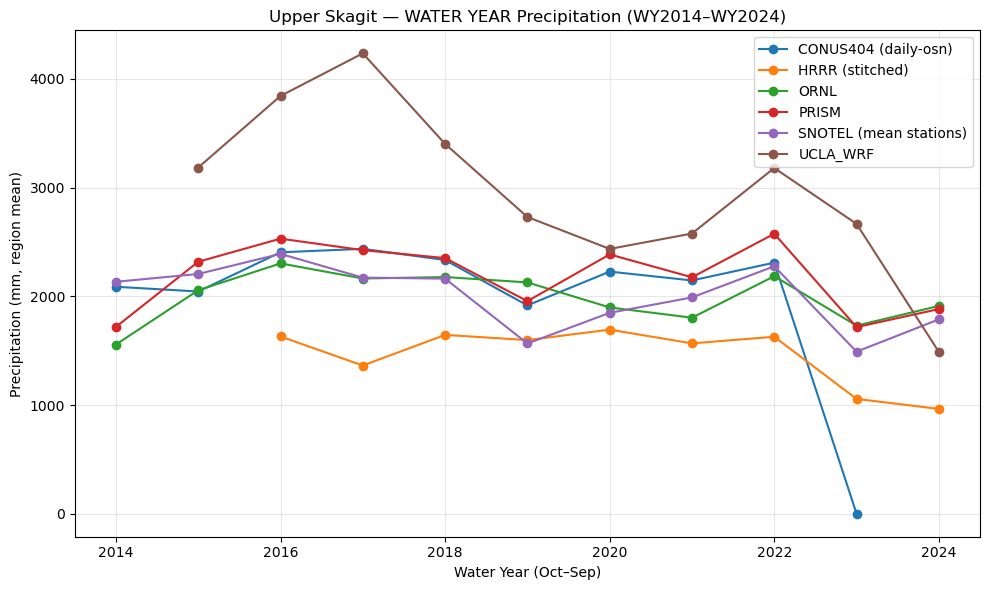

Saved plot → /data0/balaji24/data/derived/water_year_precip_Sauk_2014_2024.png


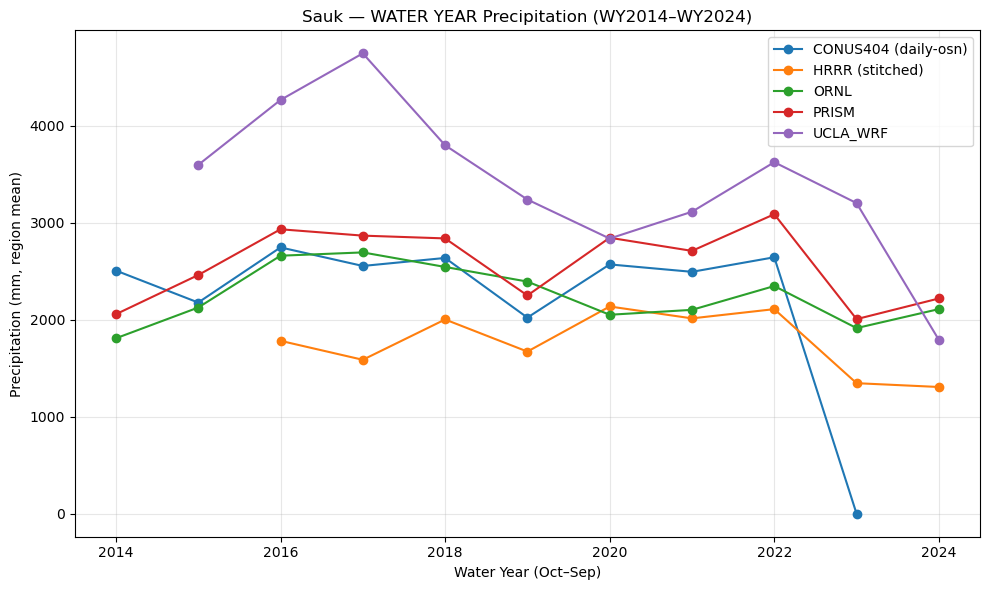

Saved plot → /data0/balaji24/data/derived/water_year_precip_Lower_Skagit_2014_2024.png


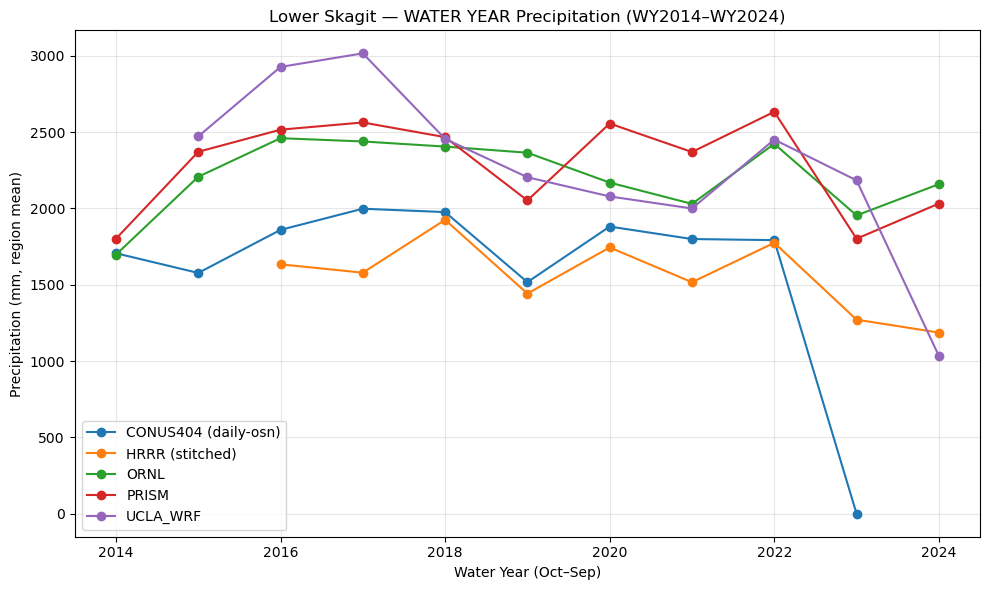

Saved summary plot → /data0/balaji24/data/derived/water_year_precip_skagit_regions_2014_2024_ALL.png


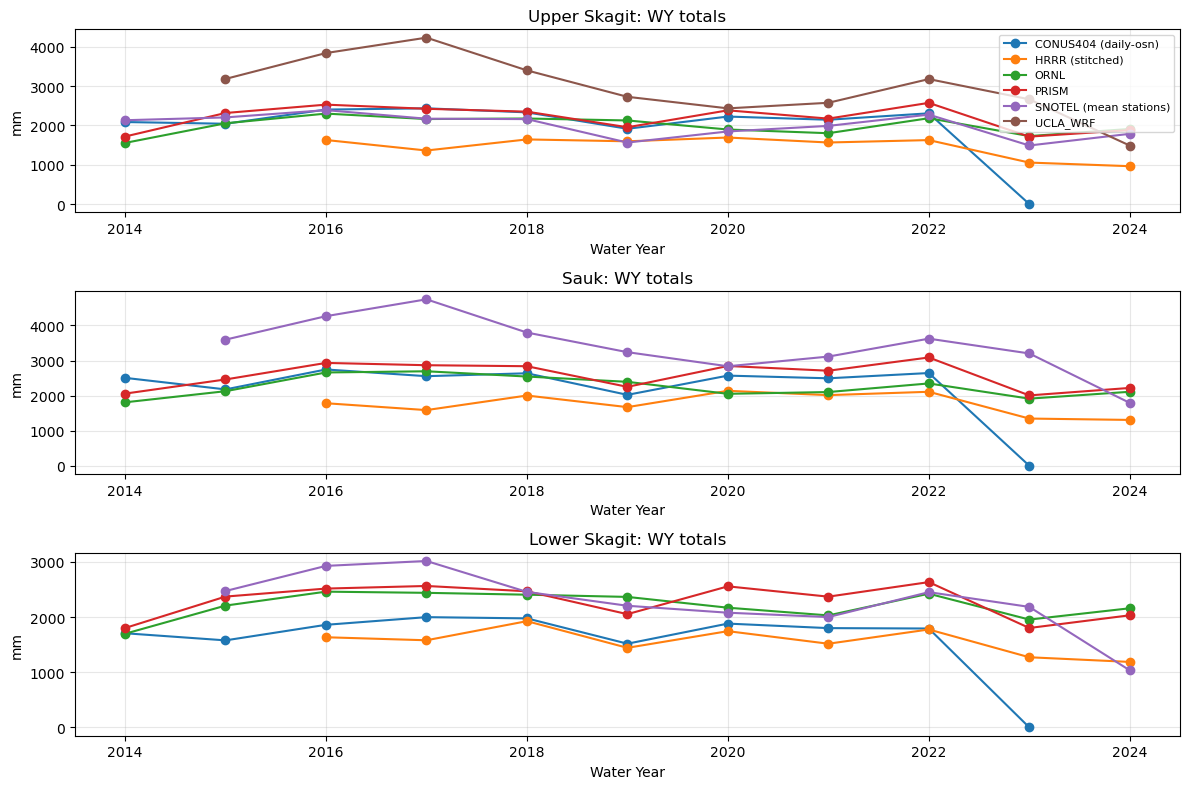


[MAE vs PRISM] Per (region, water year) (mm):
           region  year                 dataset      mae_mm
0    Lower Skagit  2014    CONUS404 (daily-osn)   94.444363
1    Lower Skagit  2014         HRRR (stitched)         NaN
2    Lower Skagit  2014                    ORNL  103.844576
3    Lower Skagit  2014  SNOTEL (mean stations)         NaN
4    Lower Skagit  2014                UCLA_WRF         NaN
..            ...   ...                     ...         ...
160  Upper Skagit  2024    CONUS404 (daily-osn)         NaN
161  Upper Skagit  2024         HRRR (stitched)  918.898812
162  Upper Skagit  2024                    ORNL   28.723287
163  Upper Skagit  2024  SNOTEL (mean stations)   95.216084
164  Upper Skagit  2024                UCLA_WRF  393.991977

[165 rows x 4 columns]
Saved MAE CSV → /data0/balaji24/data/derived/water_year_mae_vs_PRISM_skagit_regions_2014_2024.csv
Saved MAE plot → /data0/balaji24/data/derived/water_year_mae_vs_PRISM_Upper_Skagit_2014_2024.png


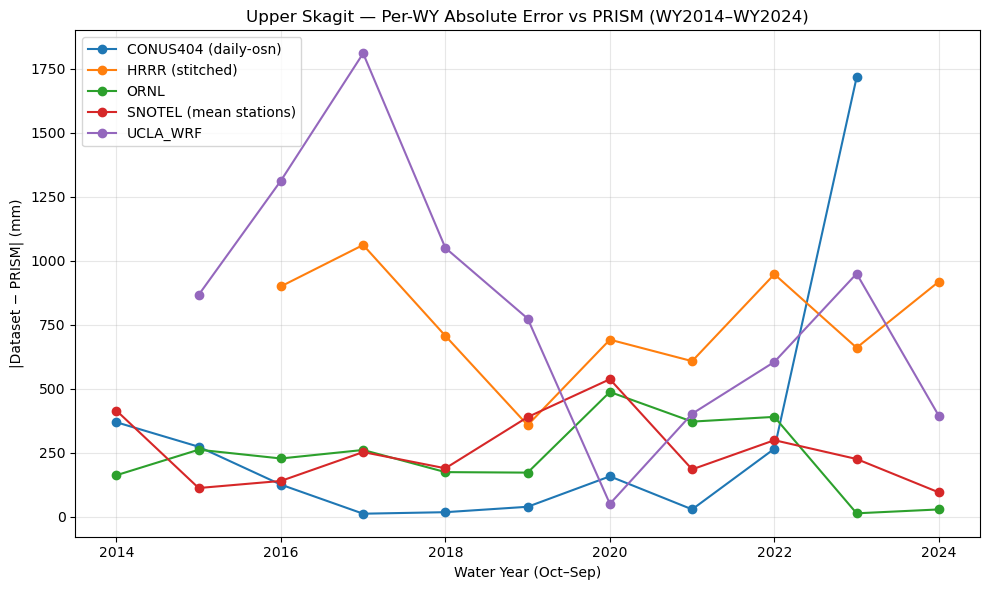

Saved MAE plot → /data0/balaji24/data/derived/water_year_mae_vs_PRISM_Sauk_2014_2024.png


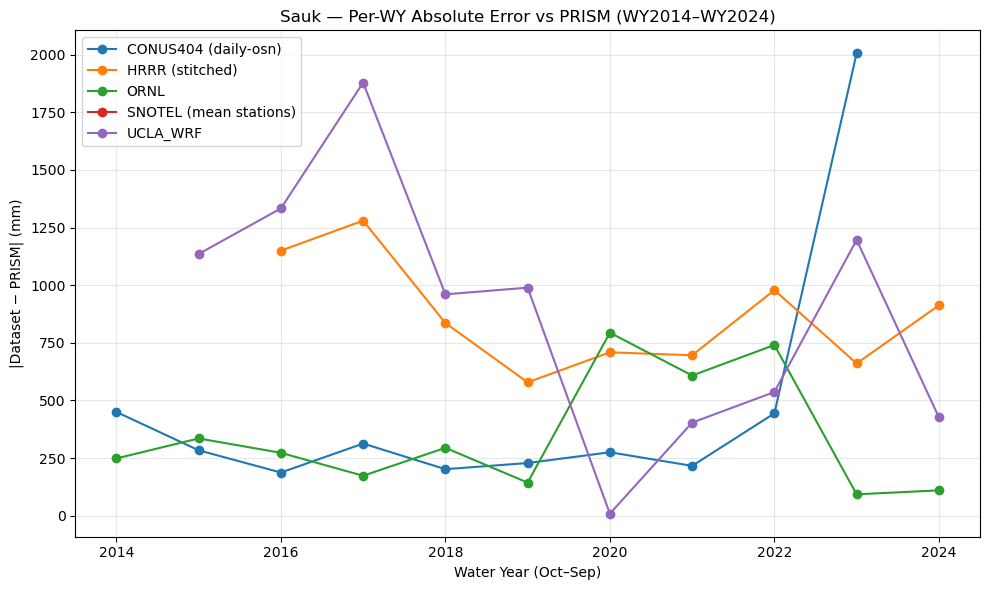

Saved MAE plot → /data0/balaji24/data/derived/water_year_mae_vs_PRISM_Lower_Skagit_2014_2024.png


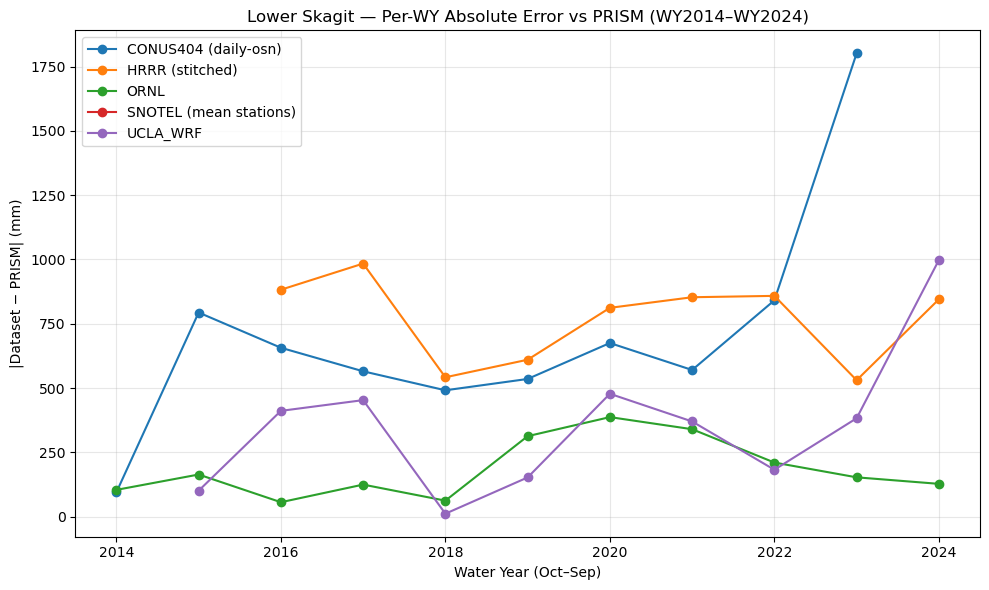

Saved MAE summary plot → /data0/balaji24/data/derived/water_year_mae_vs_PRISM_skagit_regions_2014_2024.png


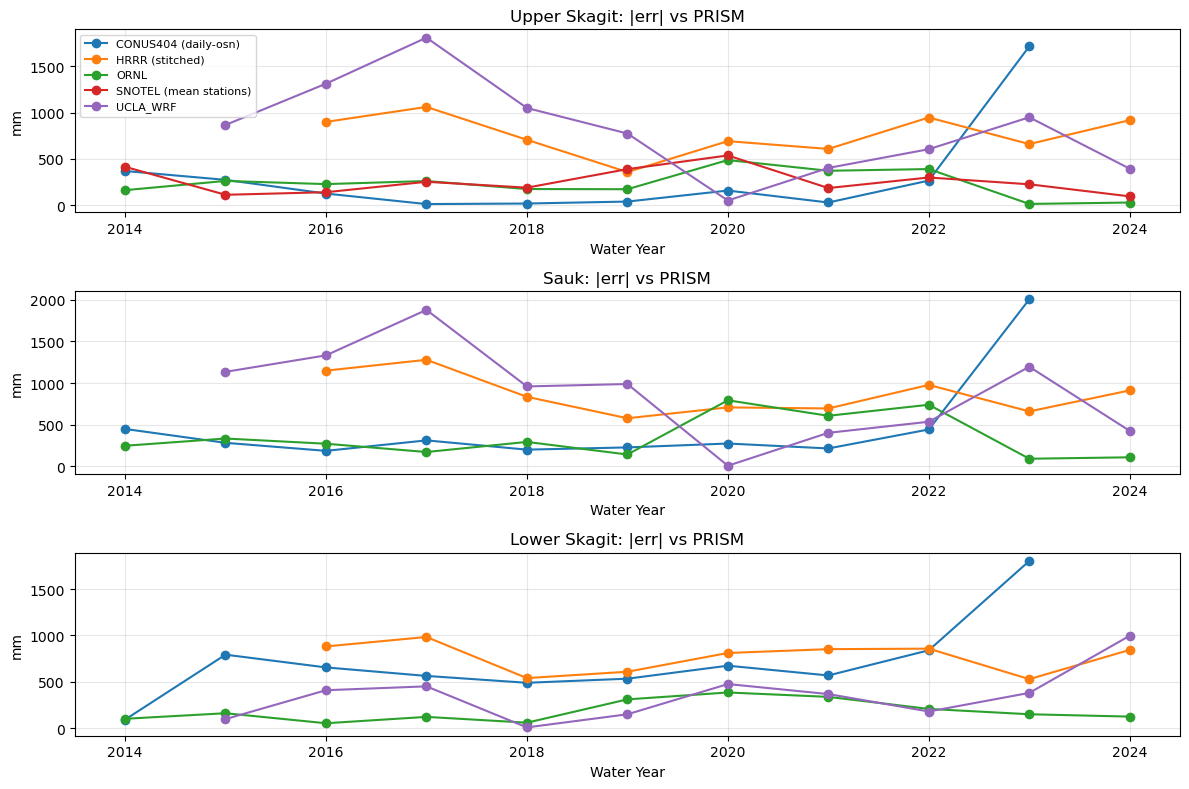

In [2]:
# ============================
# Skagit Basin — WATER YEAR Precip (mm) by dataset (WY2014–WY2024)
# NOW BY 3 REGIONS (HUC8-dominant sub-basins):
#   - Upper Skagit
#   - Sauk
#   - Lower Skagit
#
# Safe, de-accumulating where needed, robust to duplicates
#
# WATER YEAR: Oct 1 → Sep 30, labeled by ending year
#   (WY2014 = 2013-10-01..2014-09-30)
#
# FIXES kept:
# - HRRR: correct WY month selection + robust concat (precip-only concat + mask from first month)
# - UCLA: correct WY by combining wy-1 and wy yearly zarrs + slicing Oct–Sep
#
# ADD:
# - Per-(region,WY) absolute error (|err|) vs PRISM for all other datasets
# ============================

import json, re
from pathlib import Path
from glob import glob
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# ---------------- Config ----------------
BASE = Path("/data0/balaji24/data")
BOUNDARY_GEO = Path("../data/GIS/SkagitBoundary.json")
HUC8_GEO     = Path("../data/GIS/SkagitSubBasin_HUC8.geojson")

YEAR_MIN, YEAR_MAX = 2014, 2024   # WATER YEAR labels

# dataset roots
P_ORNL_DIR   = BASE / "ornl"
P_PRISM_DIR  = BASE / "prism_ppt"
P_HRRR_DIR   = BASE / "weather_data"             # many YYYY-MM_HRRR_data.zarr
P_WRF_DIR    = BASE / "ucla_wrf_outputs"         # yearly zarrs
PNNL_HIST    = BASE / "PNNL" / "historical"      # hourly NetCDFs per year

OUT = BASE / "derived"
OUT.mkdir(parents=True, exist_ok=True)

CSV_OUT = OUT / f"water_year_precip_skagit_regions_{YEAR_MIN}_{YEAR_MAX}_ALL.csv"
PNG_OUT = OUT / f"water_year_precip_skagit_regions_{YEAR_MIN}_{YEAR_MAX}_ALL.png"

MAE_REF = "PRISM"
MAE_CSV_OUT = OUT / f"water_year_mae_vs_{MAE_REF}_skagit_regions_{YEAR_MIN}_{YEAR_MAX}.csv"
MAE_PNG_OUT = OUT / f"water_year_mae_vs_{MAE_REF}_skagit_regions_{YEAR_MIN}_{YEAR_MAX}.png"

REGION_NAMES = ["Upper Skagit", "Sauk", "Lower Skagit"]

# ---------------- Helpers ----------------
def safe_open_zarr(p: Path):
    try:
        return xr.open_zarr(p, consolidated=True)
    except Exception:
        return xr.open_zarr(p, consolidated=False)

def find_lat_lon_names(ds):
    lat_name = next((n for n in ["lat","latitude","XLAT","XLAT_M"] if n in ds), None)
    lon_name = next((n for n in ["lon","longitude","XLONG","XLONG_M"] if n in ds), None)
    return lat_name, lon_name

def ensure_time_sorted_unique(da):
    if "time" not in da.dims:
        return da
    da = da.sortby("time")
    try:
        t = xr.DataArray(da["time"].values)
        _, idx = np.unique(t.values, return_index=True)
        da = da.isel(time=np.sort(idx))
    except Exception:
        pass
    return da

def to_incremental_mm(da, force_cumulative=False):
    """Normalize precip to incremental per-step in mm; deaccumulate if cumulative."""
    units = str(da.attrs.get("units", "")).lower()
    name  = (da.name or "").lower()

    if units.strip() in {"m", "meter", "meters"}:
        da = da * 1000.0
        da.attrs["units"] = "mm"

    if "kg m" in units and "-2" in units:
        da.attrs["units"] = "mm"

    is_cum = (
        force_cumulative
        or any(k in name for k in ["prec_acc_nc", "rainnc", "rainc", "acc"])
        or ("cumulative" in units)
    )

    da = ensure_time_sorted_unique(da)

    if is_cum:
        inc = da.diff("time", label="upper")
        inc = inc.where(inc >= 0, 0)  # clip resets
        inc = xr.concat([da.isel(time=slice(0, 1)) * 0, inc], dim="time")
        inc.attrs["units"] = "mm"
        return inc

    return da

# ---------------- Region handling ----------------
def load_regions_gdf():
    """Load the 3 dominant HUC8 polygons, clipped to Skagit boundary."""
    import geopandas as gpd

    skagit_gdf = gpd.read_file(BOUNDARY_GEO).to_crs("EPSG:4326")
    huc8 = gpd.read_file(HUC8_GEO).to_crs("EPSG:4326")

    huc8_3 = huc8[huc8["Name"].isin(REGION_NAMES)].copy()
    if huc8_3.empty:
        raise ValueError(
            f"No matching HUC8 regions found for {REGION_NAMES}. "
            f"Check HUC8_GEO path and the 'Name' field values."
        )

    huc8_3 = gpd.overlay(huc8_3, skagit_gdf, how="intersection")
    regions_gdf = huc8_3[["Name", "geometry"]].reset_index(drop=True)

    regions_gdf["Name"] = pd.Categorical(regions_gdf["Name"], categories=REGION_NAMES, ordered=True)
    regions_gdf = regions_gdf.sort_values("Name").reset_index(drop=True)
    return regions_gdf

def _to_2d(arr):
    if "time" in arr.dims:
        arr = arr.isel(time=0)
    for d in list(arr.dims):
        if arr.sizes[d] == 1:
            arr = arr.isel({d: 0})
    while arr.ndim > 2:
        extra = [d for d in arr.dims if d not in ("x","y","lon","lat")]
        if not extra:
            break
        arr = arr.isel({extra[0]: 0})
    return arr

def region_mean(da, grid_ds=None, regions_gdf=None):
    """
    Mean(da) inside each region polygon.
    Returns DataArray with added 'region' dimension.
    """
    if regions_gdf is None:
        raise ValueError("regions_gdf is required for region_mean")
    try:
        import regionmask
    except Exception as e:
        raise RuntimeError(f"regionmask is required for region_mean: {e}")

    time_dim = "time" if "time" in da.dims else None
    spatial = [d for d in da.dims if d != time_dim]
    if not spatial:
        out = da
        return out.expand_dims(region=list(regions_gdf["Name"].values))

    host = grid_ds if grid_ds is not None else da.to_dataset(name="_tmp")
    lat_name, lon_name = find_lat_lon_names(host)
    if not (lat_name and lon_name):
        out = da.mean(spatial, skipna=True)
        return out.expand_dims(region=list(regions_gdf["Name"].values))

    lon = _to_2d(host[lon_name])
    lat = _to_2d(host[lat_name])

    regs = regionmask.Regions(
        outlines=list(regions_gdf.geometry.values),
        names=list(regions_gdf["Name"].astype(str).values),
        numbers=list(range(len(regions_gdf))),
        name="Skagit_3HUC8",
    )

    rid = regs.mask(lon, lat)

    out_list = []
    for i, rname in enumerate(regs.names):
        m = (rid == i)
        w = xr.where(m, 1.0, np.nan)
        out_list.append((da * w).mean(spatial, skipna=True))

    out = xr.concat(out_list, dim="region")
    out = out.assign_coords(region=regs.names)
    return out

# ---------------- WATER YEAR helpers ----------------
def wy_start(wy: int) -> str:
    return f"{wy-1}-10-01"

def wy_end(wy: int) -> str:
    return f"{wy}-09-30"

def water_year_index(time_da):
    return xr.where(time_da.dt.month >= 10, time_da.dt.year + 1, time_da.dt.year)

def water_year_sum_mm(da):
    """
    Sum over water years grouped by WY label.
    Works for da dims like ('time','region') or ('time',).
    Returns da with dim 'year' (and 'region' if present).
    """
    if "time" not in da.dims:
        out = xr.DataArray(da).rename("mm")
        return out
    da = ensure_time_sorted_unique(da)
    wy = water_year_index(da["time"])
    out = da.groupby(wy).sum("time", skipna=True)
    out = out.rename({"group": "year"}) if "group" in out.dims else out
    out.name = "mm"
    return out

def pick_wy(ann, wy):
    """(Legacy helper) for non-region paths; kept for compatibility."""
    try:
        if "year" in ann.coords:
            return float(ann.sel(year=wy).values)
        for c in ann.coords:
            if "year" in str(c):
                return float(ann.sel({c: wy}).values)
        return float(ann.values.item())
    except Exception:
        return np.nan

# --------- HRRR robust deaccumulation ----------
def deaccumulate_generic(da, time_dim="time", clip_zero=True):
    run_coord = next((c for c in ("run", "init", "forecast_reference_time") if c in da.coords), None)
    step_coord = next((c for c in ("step", "lead", "forecast_hour") if c in da.coords), None)
    if run_coord and step_coord:
        dif = da.sortby([run_coord, step_coord]).diff(step_coord, label="upper")
        if clip_zero:
            dif = xr.where(dif < 0, 0, dif)
        return dif.fillna(0)

    da = da.sortby(time_dim)
    dif = da.diff(time_dim, label="upper")
    if clip_zero:
        dif = xr.where(dif < 0, 0, dif)
    return dif.fillna(0)

def hrrr_hourly_precip_mm(ds, var="tp"):
    da = ds[var]
    probe = da.isel({k: 0 for k in da.dims if k not in ("time", "step")})
    vals = probe.values
    is_cum = False
    if getattr(vals, "ndim", 0) == 1 and vals.size > 6:
        dif = np.diff(vals[:200] if vals.size > 200 else vals)
        is_cum = (dif >= -1e-6).mean() > 0.9
    return deaccumulate_generic(da, time_dim="time", clip_zero=True) if is_cum else da

def hrrr_month_prefixes_for_wy(wy: int):
    prev = wy - 1
    prefixes = [f"{prev}-10", f"{prev}-11", f"{prev}-12"]
    prefixes += [f"{wy}-{m:02d}" for m in range(1, 10)]
    return set(prefixes)

# ---------------- Collectors ----------------
regions_gdf = load_regions_gdf()
rows = []

GLOBAL_START = f"{YEAR_MIN-1}-10-01"
GLOBAL_END   = f"{YEAR_MAX}-09-30"

# ---------- ORNL (Daymet: mm/day) ----------
if P_ORNL_DIR.exists():
    ornl_years = sorted(P_ORNL_DIR.glob("*_ORNL_data.zarr"))
    if ornl_years:
        dso = xr.concat(
            [safe_open_zarr(p) for p in ornl_years],
            dim="time",
            join="outer",
            coords="minimal",
            compat="override",
        )
        if "prcp" in dso:
            da = ensure_time_sorted_unique(dso["prcp"])
            rm = region_mean(da, grid_ds=dso, regions_gdf=regions_gdf).sel(time=slice(GLOBAL_START, GLOBAL_END))
            ann = water_year_sum_mm(rm)  # dims: (year, region)

            for wy in range(YEAR_MIN, YEAR_MAX + 1):
                for rname in ann["region"].values:
                    try:
                        val = float(ann.sel(year=wy, region=rname).values)
                    except Exception:
                        val = np.nan
                    if not np.isnan(val):
                        rows.append({"dataset": "ORNL", "region": str(rname), "year": wy, "mm": val})

# ---------- PRISM (daily zarrs; ppt ~ mm/day) ----------
if P_PRISM_DIR.exists():
    prism_years = sorted(P_PRISM_DIR.glob("**/*_daily_4km_PRISM_data.zarr"))
    if prism_years:
        dsp = xr.concat(
            [safe_open_zarr(p) for p in prism_years],
            dim="time",
            join="outer",
            coords="minimal",
            compat="override",
        )
        v = next((v for v in ["ppt", "precip", "prcp"] if v in dsp), None)
        if v:
            da = ensure_time_sorted_unique(dsp[v])
            rm = region_mean(da, grid_ds=dsp, regions_gdf=regions_gdf).sel(time=slice(GLOBAL_START, GLOBAL_END))
            ann = water_year_sum_mm(rm)  # dims: (year, region)

            for wy in range(YEAR_MIN, YEAR_MAX + 1):
                for rname in ann["region"].values:
                    try:
                        val = float(ann.sel(year=wy, region=rname).values)
                    except Exception:
                        val = np.nan
                    if not np.isnan(val):
                        rows.append({"dataset": "PRISM", "region": str(rname), "year": wy, "mm": val})

# ======================================================================
# ---------- HRRR (monthly zarrs; WY-correct + SAFE concat + region masks)
# ======================================================================
hrrr_months = sorted(P_HRRR_DIR.glob("*.zarr"))
monthly = [p for p in hrrr_months if re.match(r"\d{4}-\d{2}_HRRR_data\.zarr", p.name)]
available = {p.name[:7] for p in monthly}

if monthly:
    available_prefixes = sorted(list(available))
    print(f"[HRRR] months available: {available_prefixes[0]} … {available_prefixes[-1]} (n={len(available_prefixes)})")

    for wy in range(YEAR_MIN, YEAR_MAX + 1):
        need = hrrr_month_prefixes_for_wy(wy)
        missing = sorted(list(need - available))
        if missing:
            print(f"[HRRR] WY{wy}: missing months {missing} -> skipping WY{wy}")
            continue

        parts = sorted([p for p in monthly if p.name[:7] in need], key=lambda p: p.name[:7])
        ds0 = safe_open_zarr(parts[0])

        var = "tp" if "tp" in ds0 else ("apcp" if "apcp" in ds0 else None)
        if not var:
            print(f"[HRRR] WY{wy}: no tp/apcp in {parts[0].name} -> skipping")
            try: ds0.close()
            except Exception: pass
            continue

        dsets = []
        ok = True
        for p in parts:
            dsm = safe_open_zarr(p)
            if var not in dsm:
                print(f"[HRRR] WY{wy}: {p.name} missing {var} -> skipping WY{wy}")
                try: dsm.close()
                except Exception: pass
                ok = False
                break
            dsets.append(dsm[[var]])

        if not ok:
            for d in dsets:
                try: d.close()
                except Exception: pass
            try: ds0.close()
            except Exception: pass
            continue

        ds = xr.concat(
            dsets,
            dim="time",
            join="outer",
            coords="minimal",
            compat="override",
        ).sortby("time")

        hourly_mm = hrrr_hourly_precip_mm(ds, var=var)
        daily = hourly_mm.resample(time="1D").sum()

        rm_daily = region_mean(daily, grid_ds=ds0, regions_gdf=regions_gdf)
        rm_daily = ensure_time_sorted_unique(rm_daily)
        rm_daily = rm_daily.sel(time=slice(wy_start(wy), wy_end(wy)))

        wy_tot = rm_daily.sum("time", skipna=True)  # dims: region
        for rname in wy_tot["region"].values:
            val = float(wy_tot.sel(region=rname).values)
            rows.append({"dataset": "HRRR (stitched)", "region": str(rname), "year": wy, "mm": val})

        print(f"[HRRR] WY{wy}: " + ", ".join([f"{r}={float(wy_tot.sel(region=r)):.1f}" for r in wy_tot["region"].values]))

        for d in dsets:
            try: d.close()
            except Exception: pass
        try: ds0.close()
        except Exception: pass
else:
    print("[HRRR] No HRRR monthly zarrs found -> skipping HRRR.")
# ======================================================================

# ---------- UCLA WRF (WY-correct: combine wy-1 and wy zarrs, then slice Oct–Sep; region masks) ----------
if P_WRF_DIR.exists():
    wrf_zarrs = sorted(P_WRF_DIR.glob("*.zarr"))
    year_to_zarr = {}
    for z in wrf_zarrs:
        m = re.search(r"(\d{4})", z.name)
        if m:
            year_to_zarr[int(m.group(1))] = z

    for wy in range(YEAR_MIN, YEAR_MAX + 1):
        z_prev = year_to_zarr.get(wy - 1)
        z_curr = year_to_zarr.get(wy)
        if z_prev is None or z_curr is None:
            print(f"[UCLA_WRF] WY{wy}: missing {wy-1} or {wy} zarr -> skipping")
            continue

        ds_prev = safe_open_zarr(z_prev)
        ds_curr = safe_open_zarr(z_curr)

        dsw = xr.concat(
            [ds_prev, ds_curr],
            dim="time",
            join="outer",
            coords="minimal",
            compat="override"
        ).sortby("time")

        v_nc = next((n for n in ["RAINNC", "rainnc"] if n in dsw), None)
        v_c  = next((n for n in ["RAINC", "rainc"] if n in dsw), None)
        if not (v_nc or v_c):
            print(f"[UCLA_WRF] WY{wy}: no RAINNC/RAINC -> skipping")
            continue

        total = None
        for vv in [v_nc, v_c]:
            if vv:
                inc = to_incremental_mm(dsw[vv], force_cumulative=True)
                total = inc if total is None else total + inc

        total = ensure_time_sorted_unique(total)
        total = total.sel(time=slice(wy_start(wy), wy_end(wy)))

        daily = total.resample(time="1D").sum()
        rm_daily = region_mean(daily, grid_ds=dsw, regions_gdf=regions_gdf)
        wy_tot = rm_daily.sum("time", skipna=True)

        for rname in wy_tot["region"].values:
            val = float(wy_tot.sel(region=rname).values)
            rows.append({"dataset": "UCLA_WRF", "region": str(rname), "year": wy, "mm": val})

# ---------- SNOTEL (mean of stations per region; station assigned to polygon) ----------
try:
    import geopandas as gpd
    import shapely.geometry as sgeom
    import requests
except ImportError as e:
    print(f"[SNOTEL] Missing dependency ({e}), skipping SNOTEL.")
else:
    print("[SNOTEL] Loading stations metadata from egagli/snotel_ccss_stations...")

    stations_url = "https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/all_stations.geojson"

    try:
        r = requests.get(stations_url, timeout=30)
        r.raise_for_status()
        gj = r.json()
    except Exception as e:
        print(f"[SNOTEL] Failed to download stations GeoJSON: {e}")
        stations = None
    else:
        records, geoms = [], []
        for feat in gj.get("features", []):
            props = feat.get("properties", {})
            geom = feat.get("geometry")
            if geom is None:
                continue
            records.append(props)
            geoms.append(sgeom.shape(geom))
        stations = gpd.GeoDataFrame(records, geometry=geoms, crs="EPSG:4326") if records else None

    if stations is None or stations.empty:
        print("[SNOTEL] No stations loaded, skipping.")
    else:
        skagit_geom = gpd.read_file(BOUNDARY_GEO).to_crs("EPSG:4326").geometry.iloc[0]
        inside = stations.geometry.within(skagit_geom)
        skagit_stations = stations[inside].copy()

        desired_names = {"Beaver Pass", "Brown Top", "Marten Ridge", "Rainy Pass", "Swamp Creek", "Thunder Basin"}
        if not skagit_stations.empty and "name" in skagit_stations.columns:
            skagit_stations = skagit_stations[skagit_stations["name"].isin(desired_names)]

        if skagit_stations.empty:
            print("[SNOTEL] No Skagit stations found after filtering, skipping.")
        else:
            regs = regions_gdf.copy().to_crs("EPSG:4326")
            skagit_stations = skagit_stations.to_crs("EPSG:4326")

            try:
                joined = gpd.sjoin(skagit_stations, regs.rename(columns={"Name":"region"}), predicate="within", how="left")
            except TypeError:
                joined = gpd.sjoin(skagit_stations, regs.rename(columns={"Name":"region"}), op="within", how="left")

            joined = joined.dropna(subset=["region"])
            if joined.empty:
                print("[SNOTEL] Stations found but none fall within the 3 regions -> skipping.")
            else:
                print("[SNOTEL] Using stations by region:")
                for region in REGION_NAMES:
                    sub = joined[joined["region"] == region]
                    if sub.empty:
                        continue
                    names = sub["name"].tolist() if "name" in sub.columns else sub["code"].tolist()
                    print(f"  - {region}: {names}")

                yearly_values = {}  # (region, wy) -> list of station totals
                base_csv_url = "https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/data"

                for _, row in joined.iterrows():
                    code = row.get("code")
                    name = row.get("name", code)
                    region = row["region"]
                    if pd.isna(code):
                        continue

                    csv_url = f"{base_csv_url}/{code}.csv"
                    try:
                        df_s = pd.read_csv(csv_url, index_col="datetime", parse_dates=True)
                    except Exception as e:
                        print(f"[SNOTEL] Failed to read {code} ({name}): {e}")
                        continue

                    if "PRCPSA" not in df_s.columns:
                        print(f"[SNOTEL] No PRCPSA for {code} ({name}), skipping.")
                        continue

                    precip_mm = (df_s["PRCPSA"] * 1000.0).loc[GLOBAL_START:GLOBAL_END]
                    wy_idx = np.where(precip_mm.index.month >= 10, precip_mm.index.year + 1, precip_mm.index.year)
                    tmp = pd.DataFrame({"mm": precip_mm.values, "wy": wy_idx}, index=precip_mm.index)
                    annual = tmp.groupby("wy")["mm"].sum()

                    for wy, val in annual.items():
                        wy = int(wy)
                        if YEAR_MIN <= wy <= YEAR_MAX:
                            yearly_values.setdefault((region, wy), []).append(float(val))

                for (region, wy), vals in yearly_values.items():
                    rows.append({
                        "dataset": "SNOTEL (mean stations)",
                        "region": str(region),
                        "year": int(wy),
                        "mm": float(np.nanmean(np.array(vals, dtype="float64"))),
                    })

# ---------- PNNL (regional) ----------
# Requires a precomputed 3-region mask on the PNNL grid.
PNNL_REGION_MASK = Path("/home/balaji24/skagit-met/analysis/skagit_huc8_3mask_pnnl_450x450.nc")

if PNNL_HIST.exists() and PNNL_REGION_MASK.exists():
    mask_ds = xr.open_dataset(PNNL_REGION_MASK)
    if "mask" not in mask_ds:
        raise ValueError("[PNNL] Expected variable 'mask' in PNNL_REGION_MASK")
    if "region" not in mask_ds["mask"].dims:
        raise ValueError("[PNNL] Expected 'mask' to have a 'region' dimension")

    region_labels = [str(r) for r in mask_ds["region"].values]

    for wy in range(YEAR_MIN, YEAR_MAX + 1):
        files = []
        files += sorted(glob(str(PNNL_HIST / f"{wy-1}" / "*PREC_ACC_NC*.nc")))
        files += sorted(glob(str(PNNL_HIST / f"{wy}"   / "*PREC_ACC_NC*.nc")))
        if not files:
            continue

        dsp = xr.open_mfdataset(files, combine="by_coords", engine="netcdf4", parallel=False)
        v = next((vv for vv in dsp.data_vars if "PREC_ACC_NC" in vv), None)
        if v is None:
            dsp.close()
            continue

        p = ensure_time_sorted_unique(dsp[v]).sel(time=slice(wy_start(wy), wy_end(wy)))
        if p.sizes.get("time", 0) == 0:
            dsp.close()
            continue

        Pwy = p.sum(dim="time").values  # (y,x)
        for rname in region_labels:
            m = mask_ds["mask"].sel(region=rname).values.astype(bool)
            if Pwy.shape != m.shape:
                raise ValueError(f"[PNNL] Shape mismatch: {Pwy.shape} vs mask {m.shape} for region {rname}")
            rows.append({"dataset": "PNNL (historical)", "region": rname, "year": wy, "mm": float(Pwy[m].mean())})

        dsp.close()
else:
    if PNNL_HIST.exists():
        print("[PNNL] Skipping regional PNNL: missing region mask file:", PNNL_REGION_MASK)

# ---------- CONUS404 (daily-osn; region masks) ----------
try:
    import intake
    import geopandas as gpd
    import shapely
except ImportError as e:
    print(f"[CONUS404] Missing dependency ({e}), skipping CONUS404.")
else:
    print("[CONUS404] Loading from HyTEST (conus404-daily-osn)...")
    url = "https://raw.githubusercontent.com/hytest-org/hytest/main/dataset_catalog/hytest_intake_catalog.yml"
    cat = intake.open_catalog(url)
    ds = cat["conus404-catalog"]["conus404-daily-osn"].to_dask()

    var = "PREC_ACC_NC"
    if var in ds.data_vars:
        precip = ds[var].sel(time=slice(GLOBAL_START, GLOBAL_END))
        lat = ds["lat"]
        lon = ds["lon"]

        regs = regions_gdf.to_crs("EPSG:4326")

        for region in REGION_NAMES:
            geom = regs.loc[regs["Name"] == region, "geometry"].iloc[0]
            mask_np = shapely.contains_xy(geom, lon.values, lat.values)
            mask_da = xr.DataArray(mask_np, dims=("y", "x"))

            region_daily = precip.where(mask_da).mean(dim=("y", "x"))
            region_wy = water_year_sum_mm(region_daily)

            for wy in range(YEAR_MIN, YEAR_MAX + 1):
                val = pick_wy(region_wy, wy)
                if not np.isnan(val):
                    rows.append({"dataset": "CONUS404 (daily-osn)", "region": region, "year": wy, "mm": float(val)})

# ---------------- Results: WY totals ----------------
df = (
    pd.DataFrame(rows)
      .groupby(["dataset", "region", "year"], as_index=False)
      .agg(mm=("mm", "sum"))
      .sort_values(["region", "dataset", "year"])
      .reset_index(drop=True)
)

print(df)
df.to_csv(CSV_OUT, index=False)
print("Saved CSV →", CSV_OUT)

# ---------------- Plotting: WY totals ----------------
# One figure per region
for region in REGION_NAMES:
    df_r = df[df["region"] == region]
    if df_r.empty:
        continue

    plt.figure(figsize=(10, 6))
    for name, g in df_r.groupby("dataset"):
        plt.plot(g["year"], g["mm"], marker="o", label=name)
    plt.xlabel("Water Year (Oct–Sep)")
    plt.ylabel("Precipitation (mm, region mean)")
    plt.title(f"{region} — WATER YEAR Precipitation (WY{YEAR_MIN}–WY{YEAR_MAX})")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    out_png = OUT / f"water_year_precip_{region.replace(' ','_')}_{YEAR_MIN}_{YEAR_MAX}.png"
    plt.savefig(out_png, dpi=160)
    print("Saved plot →", out_png)
    plt.show()

# Save a combined summary plot (optional): region panels, WY totals by dataset
fig = plt.figure(figsize=(12, 8))
for i, region in enumerate(REGION_NAMES, start=1):
    ax = plt.subplot(3, 1, i)
    sub = df[df["region"] == region]
    for name, g in sub.groupby("dataset"):
        ax.plot(g["year"], g["mm"], marker="o", label=name)
    ax.set_title(f"{region}: WY totals")
    ax.set_xlabel("Water Year")
    ax.set_ylabel("mm")
    ax.grid(True, alpha=0.3)
    if i == 1:
        ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(PNG_OUT, dpi=160)
print("Saved summary plot →", PNG_OUT)
plt.show()

# ==========================================================
# NEW: Per-(region,WY) MAE (absolute error) vs PRISM
#   Since there is ONE value per WY, "MAE per year" == |err|
# ==========================================================
wide = df.pivot_table(index=["region", "year"], columns="dataset", values="mm", aggfunc="first")

if MAE_REF not in wide.columns:
    raise ValueError(f"[MAE] Reference dataset '{MAE_REF}' not found. Available: {list(wide.columns)}")

abs_err = (wide.sub(wide[MAE_REF], axis=0)).abs()
abs_err = abs_err.drop(columns=[MAE_REF], errors="ignore")

mae_long = (
    abs_err.reset_index()
           .melt(id_vars=["region", "year"], var_name="dataset", value_name="mae_mm")
           .sort_values(["region", "year", "dataset"])
           .reset_index(drop=True)
)

print("\n[MAE vs PRISM] Per (region, water year) (mm):")
print(mae_long)

mae_long.to_csv(MAE_CSV_OUT, index=False)
print("Saved MAE CSV →", MAE_CSV_OUT)

# Plot MAE: one figure per region
for region in REGION_NAMES:
    try:
        sub = abs_err.xs(region, level="region")
    except Exception:
        continue

    plt.figure(figsize=(10, 6))
    for name in sub.columns:
        plt.plot(sub.index, sub[name], marker="o", label=name)

    plt.xlabel("Water Year (Oct–Sep)")
    plt.ylabel(f"|Dataset − {MAE_REF}| (mm)")
    plt.title(f"{region} — Per-WY Absolute Error vs {MAE_REF} (WY{YEAR_MIN}–WY{YEAR_MAX})")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    out_png = OUT / f"water_year_mae_vs_{MAE_REF}_{region.replace(' ','_')}_{YEAR_MIN}_{YEAR_MAX}.png"
    plt.savefig(out_png, dpi=160)
    print("Saved MAE plot →", out_png)
    plt.show()

# Save a combined MAE summary plot (optional): region panels, WY abs error by dataset
fig = plt.figure(figsize=(12, 8))
for i, region in enumerate(REGION_NAMES, start=1):
    ax = plt.subplot(3, 1, i)
    sub = abs_err.xs(region, level="region") if region in abs_err.index.get_level_values("region") else None
    if sub is None:
        ax.set_title(f"{region}: (no data)")
        ax.grid(True, alpha=0.3)
        continue
    for name in sub.columns:
        ax.plot(sub.index, sub[name], marker="o", label=name)
    ax.set_title(f"{region}: |err| vs {MAE_REF}")
    ax.set_xlabel("Water Year")
    ax.set_ylabel("mm")
    ax.grid(True, alpha=0.3)
    if i == 1:
        ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(MAE_PNG_OUT, dpi=160)
print("Saved MAE summary plot →", MAE_PNG_OUT)
plt.show()



================ 2006 (2006-03-01 → 2006-04-30) ================
  - PRISM 4km: (not available)
  - PRISM 800m: (not available)
  - ORNL Daymet: (not available)
  - UCLA WRF: (not available)
  - PNNL hist: var='PREC_ACC_NC', units='mm'
    [PNNL hist :: Upper Skagit] accum-check: frac_neg=0.489, mean_raw=0.1997, mean_diff_pos=0.03219

===== VERIFY: PNNL hist :: Upper Skagit =====
  median dt (hours): 24.00

[PNNL hist :: Upper Skagit] DAILY CHECK
  min: 0.0
  max: 19.181419372558594
  mean: 2.8119077682495117
  sum: 171.5263671875
  CHECK: daily.sum vs cum[-1]: 171.5263671875 171.52635192871094  | diff: 1.52587890625e-05
  TOP 5 daily values:
    2006-03-09 19.181419372558594
    2006-04-14 18.09351348876953
    2006-04-16 10.063133239746094
    2006-04-09 8.31646728515625
    2006-03-07 7.54217529296875
    [PNNL hist :: Sauk] accum-check: frac_neg=0.461, mean_raw=0.2109, mean_diff_pos=0.0401

===== VERIFY: PNNL hist :: Sauk =====
  median dt (hours): 24.00

[PNNL hist :: Sauk] DAILY

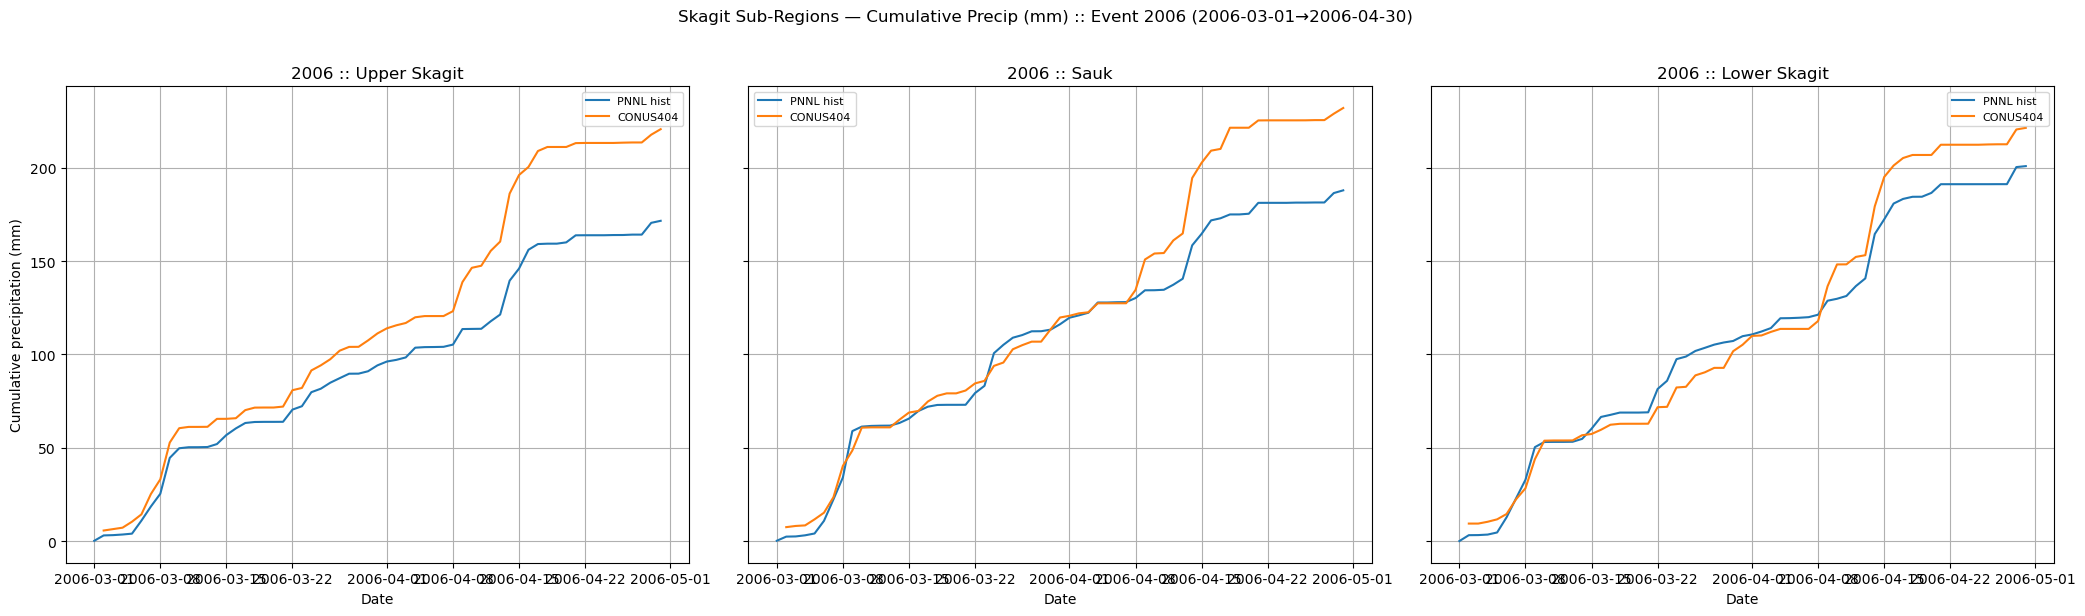


[MAE vs PRISM] reference = PRISM 800m
  -> No PRISM reference available for MAE. Skipping MAE for this event.

================ 2007 (2007-02-01 → 2007-03-31) ================
  - PRISM 4km: (not available)
  - PRISM 800m: (not available)
  - ORNL Daymet: (not available)
  - UCLA WRF: (not available)
  - PNNL hist: var='PREC_ACC_NC', units='mm'
    [PNNL hist :: Upper Skagit] accum-check: frac_neg=0.496, mean_raw=0.516, mean_diff_pos=0.05909

===== VERIFY: PNNL hist :: Upper Skagit =====
  median dt (hours): 24.00

[PNNL hist :: Upper Skagit] DAILY CHECK
  min: 0.0
  max: 49.38722229003906
  mean: 6.865825653076172
  sum: 405.0837097167969
  CHECK: daily.sum vs cum[-1]: 405.0837097167969 405.08367919921875  | diff: 3.0517578125e-05
  TOP 5 daily values:
    2007-03-11 49.38722229003906
    2007-03-12 37.04659652709961
    2007-03-24 34.490970611572266
    2007-02-18 21.124685287475586
    2007-02-15 20.699737548828125
    [PNNL hist :: Sauk] accum-check: frac_neg=0.482, mean_raw=0.578

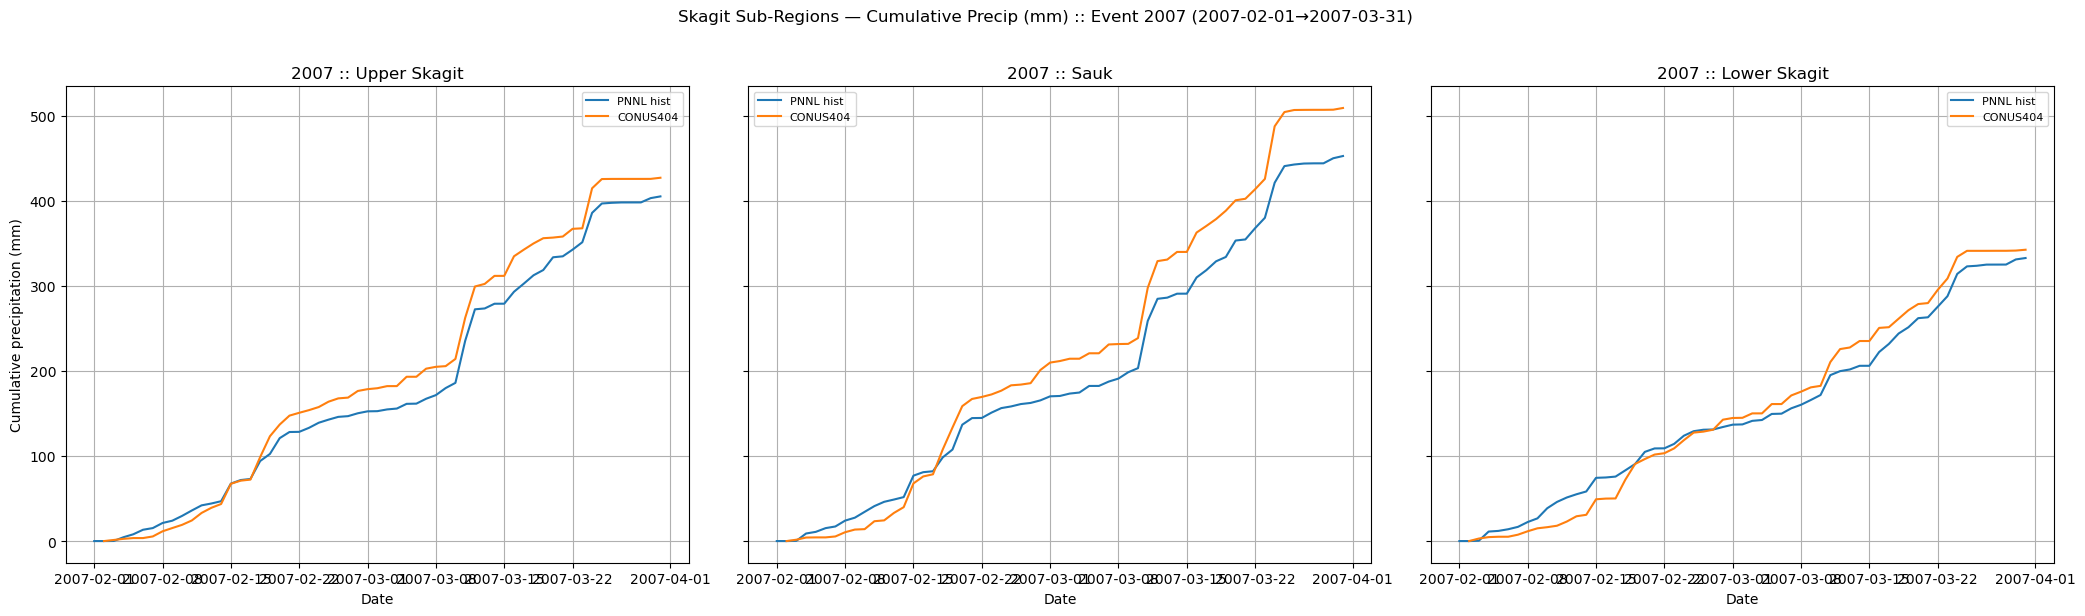


[MAE vs PRISM] reference = PRISM 800m
  -> No PRISM reference available for MAE. Skipping MAE for this event.

================ 2008 (2008-03-01 → 2008-04-30) ================
  - PRISM 4km: (not available)
  - PRISM 800m: (not available)
  - ORNL Daymet: (not available)
  - UCLA WRF: (not available)
  - PNNL hist: var='PREC_ACC_NC', units='mm'
    [PNNL hist :: Upper Skagit] accum-check: frac_neg=0.482, mean_raw=0.225, mean_diff_pos=0.03104

===== VERIFY: PNNL hist :: Upper Skagit =====
  median dt (hours): 24.00

[PNNL hist :: Upper Skagit] DAILY CHECK
  min: 1.008619619824458e-06
  max: 12.617003440856934
  mean: 2.982661724090576
  sum: 181.94236755371094
  CHECK: daily.sum vs cum[-1]: 181.94236755371094 181.9423065185547  | diff: 6.103515625e-05
  TOP 5 daily values:
    2008-03-01 12.617003440856934
    2008-03-04 11.421232223510742
    2008-03-23 10.401535034179688
    2008-03-03 10.083930015563965
    2008-03-24 8.815570831298828
    [PNNL hist :: Sauk] accum-check: frac_neg=0

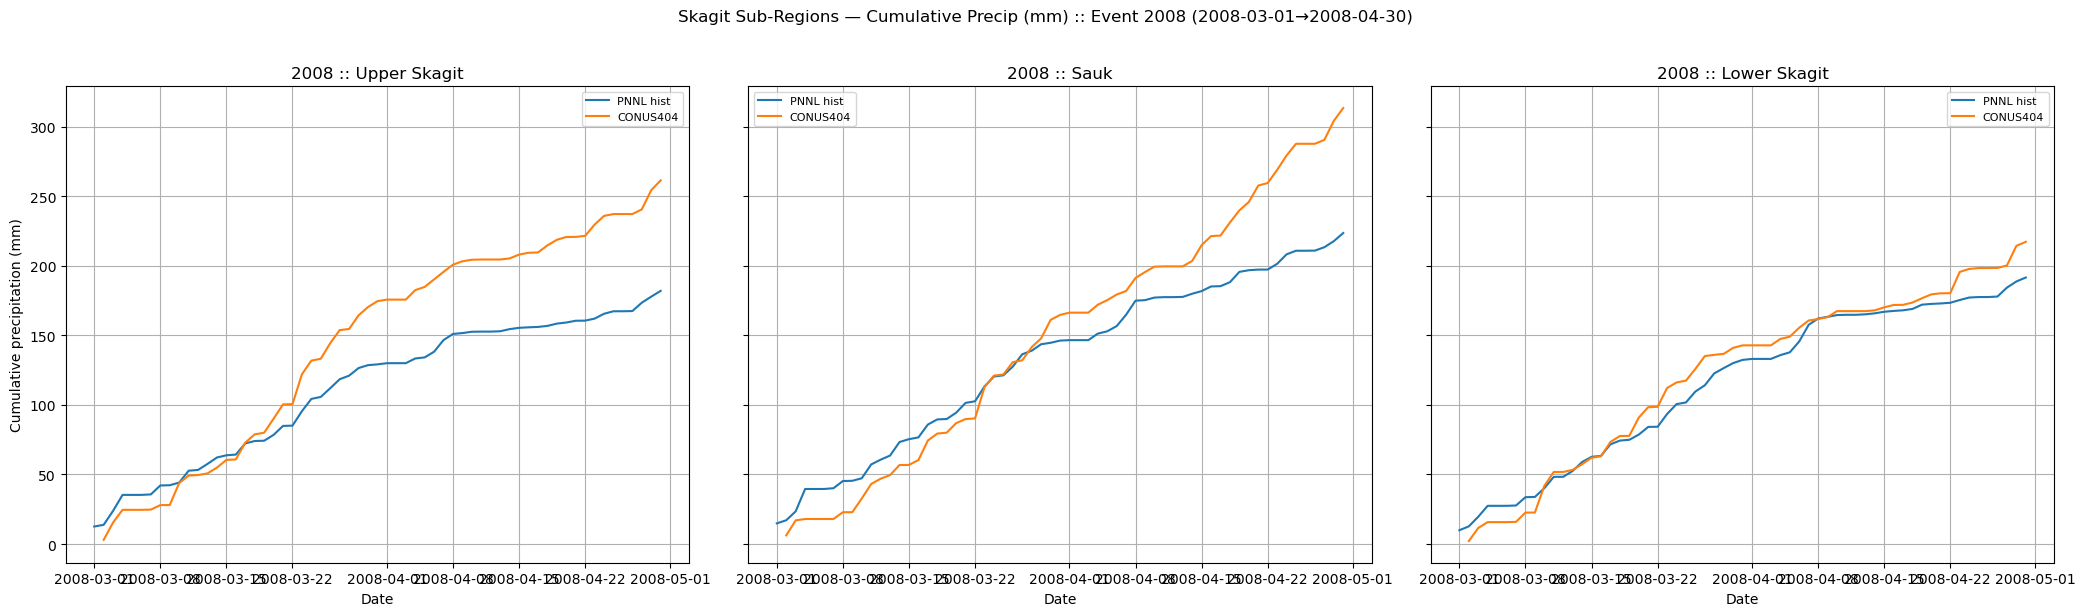


[MAE vs PRISM] reference = PRISM 800m
  -> No PRISM reference available for MAE. Skipping MAE for this event.

No MAE rows computed (no overlaps / missing PRISM).


In [6]:
# ============================================================
# Skagit Basin – Event CUMULATIVE Precip comparison (MEMORY-SAFE) + VERIFICATION
# REGION MODE (3 sub-basins) + MAE vs PRISM (mm/day)
# ============================================================

from pathlib import Path
import re
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

import geopandas as gpd
import regionmask
import intake
import requests
import shapely

# ----------------------------
# PATHS
# ----------------------------
BASE = Path("/data0/balaji24/data")

P_PRISM_DIR  = BASE / "prism_ppt"
P_ORNL_DIR   = BASE / "ornl"
P_UCLA_DIR   = BASE / "ucla_wrf_outputs"

P_PNNL_DIR   = BASE / "PNNL" / "historical"
P_PNNL_GEO   = P_PNNL_DIR / "SERDP6km.geo_em.d01.nc"

BOUNDARY_GEO = Path("/home/balaji24/skagit-met/data/GIS/SkagitBoundary.json")
HUC8_FILE    = Path("/home/balaji24/skagit-met/data/GIS/SkagitSubBasin_HUC8.geojson")  # adjust if needed

CONUS_INTAKE_YML = (
    "https://raw.githubusercontent.com/hytest-org/hytest/main/"
    "dataset_catalog/hytest_intake_catalog.yml"
)
CONUS_MAX_TIME = np.datetime64("2022-10-01")

SNOTEL_STATIONS_GEOJSON = (
    "https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/all_stations.geojson"
)

OUT = BASE / "derived"
OUT.mkdir(parents=True, exist_ok=True)
MAE_CSV_OUT = OUT / "event_region_mae_vs_prism4km_mm_per_day.csv"

# ----------------------------
# EVENTS
# ----------------------------
events = {
    2006: ("2006-03-01", "2006-04-30"),
    2007: ("2007-02-01", "2007-03-31"),
    2008: ("2008-03-01", "2008-04-30"),
}

# ----------------------------
# REGION SETUP (Top 3 HUC8 inside Skagit)
# ----------------------------
REGION_NAMES = ["Upper Skagit", "Sauk", "Lower Skagit"]

def load_huc8_geoms_for_regions():
    skagit = gpd.read_file(BOUNDARY_GEO).to_crs("EPSG:4326")
    sk_geom = skagit.geometry.iloc[0]

    huc8 = gpd.read_file(HUC8_FILE).to_crs("EPSG:4326")
    if "Name" not in huc8.columns:
        raise RuntimeError(f"HUC8 file missing 'Name'. Columns={list(huc8.columns)}")

    h = huc8[huc8["Name"].isin(REGION_NAMES)].copy()
    if h.empty:
        raise RuntimeError(f"No matching HUC8 rows for {REGION_NAMES} in {HUC8_FILE}")

    h["geometry"] = h.geometry.intersection(sk_geom)

    geoms = []
    for nm in REGION_NAMES:
        g = h.loc[h["Name"] == nm, "geometry"]
        if g.empty:
            raise RuntimeError(f"Missing geometry for region '{nm}' after filtering/intersection.")
        geoms.append(g.iloc[0])
    return REGION_NAMES, geoms

REGION_NAMES, REGION_GEOMS = load_huc8_geoms_for_regions()
REGIONS = regionmask.Regions(outlines=REGION_GEOMS, names=REGION_NAMES, name="SkagitHUC8Top3")

# ----------------------------
# GENERAL HELPERS
# ----------------------------
def safe_open_zarr(p):
    try:
        return xr.open_zarr(p, consolidated=True)
    except Exception:
        return xr.open_zarr(p, consolidated=False)

def pick_var(ds, names):
    for n in names:
        if n in ds.data_vars:
            return n
    return None

def units_str(ds, var):
    return ds[var].attrs.get("units", "(missing)")

def print_units(ds, var, label):
    print(f"  - {label}: var='{var}', units='{units_str(ds, var)}'")

def ensure_time_sorted(da):
    if "time" in da.dims:
        da = da.sortby("time")
    return da

def median_timestep_seconds(time_index):
    if len(time_index) < 2:
        return None
    dt = pd.Series(time_index).diff().dt.total_seconds().median()
    return float(dt) if pd.notnull(dt) else None

def ensure_daily_sum(da):
    if "time" not in da.dims:
        return da
    t = pd.to_datetime(da["time"].values)
    dt = median_timestep_seconds(t)
    if dt is None:
        return da
    return da.resample(time="1D").sum()

def is_plottable_time_region(da):
    return da is not None and ("time" in da.dims) and ("region" in da.dims) and da.sizes["time"] > 0 and da.sizes["region"] > 0

# --- critical helper: rename mask/grid dims to match precip spatial dims ---
def _rename_like_spatial(grid2d, target_spatial_dims, target_spatial_sizes):
    """
    grid2d: DataArray with 2 dims
    target_spatial_dims: (d0, d1) from precip
    target_spatial_sizes: (s0, s1) from precip
    Returns grid2d with dims renamed to match target dims, possibly transposed.
    """
    if grid2d.ndim != 2:
        raise RuntimeError(f"_rename_like_spatial expects 2D grid, got nd={grid2d.ndim}, dims={grid2d.dims}")

    dA, dB = grid2d.dims
    sA, sB = grid2d.sizes[dA], grid2d.sizes[dB]
    d0, d1 = target_spatial_dims
    s0, s1 = target_spatial_sizes

    if (sA, sB) == (s0, s1):
        return grid2d.rename({dA: d0, dB: d1})
    if (sA, sB) == (s1, s0):
        return grid2d.transpose(dB, dA).rename({dB: d0, dA: d1})

    raise RuntimeError(
        f"Cannot align grid dims {grid2d.dims} sizes {(sA,sB)} to target {target_spatial_dims} sizes {(s0,s1)}"
    )

# ----------------------------
# DASK-SAFE diagnostics
# ----------------------------
def frac_neg_dask(d):
    try:
        return float((d < 0).mean().compute())
    except Exception:
        try:
            dd = d.isel(time=slice(0, min(500, d.sizes.get("time", 0))))
            return float((dd < 0).mean().compute())
        except Exception:
            return np.nan

def mean_dask(x):
    try:
        return float(x.mean().compute())
    except Exception:
        try:
            xs = x.isel(time=slice(0, min(500, x.sizes.get("time", 0))))
            return float(xs.mean().compute())
        except Exception:
            return np.nan

# ----------------------------
# VERIFICATION (1D)
# ----------------------------
def _median_dt_hours_from_da(da):
    if da is None or "time" not in da.dims:
        return None
    t = pd.to_datetime(da["time"].values)
    if len(t) < 2:
        return None
    dt_hours = pd.Series(t).diff().dt.total_seconds().dropna().median() / 3600.0
    return float(dt_hours) if pd.notnull(dt_hours) else None

def debug_daily(label, daily_da_1d):
    if daily_da_1d is None or "time" not in daily_da_1d.dims or daily_da_1d.size == 0:
        print(f"\n[{label}] DAILY CHECK: (empty)")
        return
    daily_da_1d = daily_da_1d.dropna("time").sortby("time")
    if daily_da_1d.size == 0:
        print(f"\n[{label}] DAILY CHECK: (all NaN)")
        return
    def _c(v): return v.compute() if hasattr(v.data, "compute") else v
    print(f"\n[{label}] DAILY CHECK")
    print("  min:", float(_c(daily_da_1d.min())))
    print("  max:", float(_c(daily_da_1d.max())))
    print("  mean:", float(_c(daily_da_1d.mean())))
    print("  sum:", float(_c(daily_da_1d.sum())))

def verify_daily_and_cumsum(label, daily_da_1d, cum_da_1d=None, top_n=5):
    if daily_da_1d is None or daily_da_1d.size == 0:
        print(f"\n===== VERIFY: {label} =====\n  (no data)")
        return

    daily_da_1d = daily_da_1d.dropna("time").sortby("time")
    print(f"\n===== VERIFY: {label} =====")
    dt_hours = _median_dt_hours_from_da(daily_da_1d)
    if dt_hours is not None:
        print(f"  median dt (hours): {dt_hours:.2f}")

    debug_daily(label, daily_da_1d)

    if cum_da_1d is not None and cum_da_1d.size > 0:
        try:
            cum_last = cum_da_1d.dropna("time").isel(time=-1)
            daily_sum = daily_da_1d.sum()
            if hasattr(cum_last.data, "compute"): cum_last = cum_last.compute()
            if hasattr(daily_sum.data, "compute"): daily_sum = daily_sum.compute()
            cum_last = float(cum_last)
            daily_sum = float(daily_sum)
            print("  CHECK: daily.sum vs cum[-1]:", daily_sum, cum_last, " | diff:", daily_sum - cum_last)
        except Exception as e:
            print("  CHECK: daily.sum vs cum[-1]: (failed)", repr(e))

    try:
        top = daily_da_1d.sortby(daily_da_1d, ascending=False).isel(time=slice(0, min(top_n, daily_da_1d.size)))
        top = top.compute() if hasattr(top.data, "compute") else top
        print(f"  TOP {min(top_n, daily_da_1d.size)} daily values:")
        for tt, vv in zip(pd.to_datetime(top["time"].values), np.asarray(top.values)):
            print("   ", tt.date(), float(vv))
    except Exception as e:
        print("  TOP daily values: (failed)", repr(e))

# ----------------------------
# Accumulated precip handling (1D time)
# ----------------------------
def reset_safe_increment(acc_like_1d):
    d = acc_like_1d.diff("time")
    curr = acc_like_1d.isel(time=slice(1, None))
    inc = xr.where(d >= 0, d, curr)
    return inc.clip(min=0)

def accumulated_to_daily_mm(acc_like_1d, label):
    bm = acc_like_1d
    if bm is None or bm.sizes.get("time", 0) < 3:
        return bm.clip(min=0).resample(time="1D").sum()

    d = bm.diff("time")
    frac_neg = frac_neg_dask(d)
    mean_raw = mean_dask(bm)
    mean_diff_pos = mean_dask(d.clip(min=0))
    print(f"    [{label}] accum-check: frac_neg={frac_neg:.3f}, mean_raw={mean_raw:.4g}, mean_diff_pos={mean_diff_pos:.4g}")

    inc = reset_safe_increment(bm)
    return ensure_daily_sum(inc)

# ----------------------------
# MAE helpers (PRISM standard) — 1D only
# ----------------------------
def cum_to_daily_from_cum(cum_1d):
    if cum_1d is None or "time" not in cum_1d.dims or cum_1d.size < 2:
        return None
    cum_1d = cum_1d.dropna("time").sortby("time")
    return cum_1d.diff("time").clip(min=0)

def mae_vs_ref_daily(ref_cum_1d, other_cum_1d):
    ref_d = cum_to_daily_from_cum(ref_cum_1d)
    oth_d = cum_to_daily_from_cum(other_cum_1d)
    if ref_d is None or oth_d is None or ref_d.size == 0 or oth_d.size == 0:
        return np.nan, 0
    ref_d, oth_d = xr.align(ref_d, oth_d, join="inner")
    if ref_d.size == 0:
        return np.nan, 0
    err = (oth_d - ref_d).astype("float64")
    mae = float(np.nanmean(np.abs(err.values)))
    n = int(np.sum(np.isfinite(err.values)))
    return mae, n

# ----------------------------
# Lon/lat inference
# ----------------------------
def _infer_lonlat(ds):
    lon_candidates = ["lon", "longitude", "XLONG", "XLONG_M", "LON", "xlong", "xlong_m"]
    lat_candidates = ["lat", "latitude",  "XLAT",  "XLAT_M",  "LAT", "xlat",  "xlat_m"]

    def _get(name):
        if name in ds.coords: return ds.coords[name]
        if name in ds.data_vars: return ds.data_vars[name]
        return None

    lon = next((_get(n) for n in lon_candidates if _get(n) is not None), None)
    lat = next((_get(n) for n in lat_candidates if _get(n) is not None), None)
    if lon is None or lat is None:
        return None, None

    for d in list(lon.dims):
        if d.lower() in ("time", "times") or d == "Time":
            lon = lon.isel({d: 0})
    for d in list(lat.dims):
        if d.lower() in ("time", "times") or d == "Time":
            lat = lat.isel({d: 0})
    return lon, lat

# ----------------------------
# REGION MEAN (MEMORY-SAFE): loop over regions
# ----------------------------
def region_mean_loop(da_time_xy, lon2d, lat2d):
    spatial = [d for d in da_time_xy.dims if d != "time"]
    rid = REGIONS.mask(lon2d, lat2d)
    rid = _rename_like_spatial(rid, tuple(spatial), (da_time_xy.sizes[spatial[0]], da_time_xy.sizes[spatial[1]]))

    out = []
    for i, rname in enumerate(REGION_NAMES):
        m = (rid == i)
        bm = da_time_xy.where(m).mean(dim=spatial, skipna=True)
        out.append(bm)
    return xr.concat(out, dim="region").assign_coords(region=REGION_NAMES).transpose("time", "region")

def region_mean_loop_from_masks(da_time_xy, masks_region_xy):
    spatial = [d for d in da_time_xy.dims if d != "time"]
    out = []
    for rname in REGION_NAMES:
        m = masks_region_xy.sel(region=rname)
        m = _rename_like_spatial(m, tuple(spatial), (da_time_xy.sizes[spatial[0]], da_time_xy.sizes[spatial[1]]))
        bm = da_time_xy.where(m).mean(dim=spatial, skipna=True)
        out.append(bm)
    return xr.concat(out, dim="region").assign_coords(region=REGION_NAMES).transpose("time", "region")

# ----------------------------
# PRISM (covers-window match; local zarr)
# ----------------------------
_PRISM_NAME_RE = re.compile(
    r"(?P<s>\d{4}-\d{2}-\d{2})_(?P<e>\d{4}-\d{2}-\d{2})_daily_(?P<tag>4km|800m)_PRISM_data\.zarr$"
)

def find_prism_zarr_covering(start, end, tag):
    start = pd.Timestamp(start)
    end   = pd.Timestamp(end)
    candidates = []
    for p in P_PRISM_DIR.glob(f"*_daily_{tag}_PRISM_data.zarr"):
        m = _PRISM_NAME_RE.search(p.name)
        if not m:
            continue
        f0 = pd.Timestamp(m.group("s"))
        f1 = pd.Timestamp(m.group("e"))
        if f0 <= start and f1 >= end:
            candidates.append(((f1 - f0).days, f0, p))
    if not candidates:
        return None
    candidates.sort(key=lambda t: (t[0], -t[1].value))
    return candidates[0][2]

def load_prism_region_cum(start, end, tag, do_verify=True):
    z = find_prism_zarr_covering(start, end, tag)
    if z is None:
        print(f"  - PRISM {tag}: (not available)")
        return None

    ds = safe_open_zarr(z)
    var = pick_var(ds, ["ppt", "precip", "prcp"])
    if var is None:
        print(f"  - PRISM {tag} [{z.name}]: (no precip var found)")
        ds.close()
        return None

    print_units(ds, var, f"PRISM {tag} [{z.name}]")

    da = ensure_time_sorted(ds[var].sel(time=slice(start, end)))
    daily = ensure_daily_sum(da)

    lon, lat = _infer_lonlat(ds)
    if lon is None or lat is None:
        spatial = [d for d in daily.dims if d != "time"]
        bm = daily.mean(dim=spatial, skipna=True)
        bm = xr.concat([bm]*len(REGION_NAMES), dim="region").assign_coords(region=REGION_NAMES).transpose("time","region")
    else:
        lon2, lat2 = xr.broadcast(lon, lat) if (lon.ndim == 1 and lat.ndim == 1) else (lon, lat)
        bm = region_mean_loop(daily, lon2, lat2)

    cum = bm.cumsum("time")
    if do_verify:
        for r in REGION_NAMES:
            verify_daily_and_cumsum(f"PRISM {tag} :: {r}", bm.sel(region=r), cum.sel(region=r))
    ds.close()
    return cum

# ----------------------------
# ORNL Daymet (local zarr)
# ----------------------------
def load_ornl_region_cum(year, start, end, do_verify=True):
    z = next(P_ORNL_DIR.glob(f"{year}_{year}_ref_*ORNL_data.zarr"), None)
    if z is None:
        print("  - ORNL Daymet: (not available)")
        return None

    ds = safe_open_zarr(z)
    var = pick_var(ds, ["prcp"])
    if var is None:
        print("  - ORNL Daymet: (no prcp var)")
        ds.close()
        return None

    print_units(ds, var, f"ORNL Daymet [{z.name}]")

    da = ensure_time_sorted(ds[var].sel(time=slice(start, end)))
    daily = ensure_daily_sum(da)

    lon, lat = _infer_lonlat(ds)
    if lon is None or lat is None:
        spatial = [d for d in daily.dims if d != "time"]
        bm = daily.mean(dim=spatial, skipna=True)
        bm = xr.concat([bm]*len(REGION_NAMES), dim="region").assign_coords(region=REGION_NAMES).transpose("time","region")
    else:
        lon2, lat2 = xr.broadcast(lon, lat) if (lon.ndim == 1 and lat.ndim == 1) else (lon, lat)
        bm = region_mean_loop(daily, lon2, lat2)

    cum = bm.cumsum("time")
    if do_verify:
        for r in REGION_NAMES:
            verify_daily_and_cumsum(f"ORNL Daymet :: {r}", bm.sel(region=r), cum.sel(region=r))
    ds.close()
    return cum

# ----------------------------
# UCLA WRF (local event zarrs; accumulated handling)
# ----------------------------
def _parse_ucla_event_zarr_name(p: Path):
    name = p.name
    if not name.endswith(".zarr"):
        return None, None, None
    parts = name.split("_")
    if len(parts) < 3:
        return None, None, None
    try:
        s0 = pd.to_datetime(parts[0])
        s1 = pd.to_datetime(parts[1])
    except Exception:
        return None, None, None
    scenario = "historical" if "historical" in name else ("ssp245" if "ssp245" in name else "unknown")
    return s0, s1, scenario

def find_ucla_zarr_event(start, end):
    if not P_UCLA_DIR.exists():
        return None

    s0 = pd.to_datetime(start)
    s1 = pd.to_datetime(end)

    exact = P_UCLA_DIR / f"{s0:%Y-%m-%d}_{s1:%Y-%m-%d}_wrf_cesm2_r11i1p1f1_historical_data.zarr"
    if exact.exists():
        return exact

    exact_ssp = P_UCLA_DIR / f"{s0:%Y-%m-%d}_{s1:%Y-%m-%d}_wrf_cesm2_r11i1p1f1_ssp245_data.zarr"
    if exact_ssp.exists():
        return exact_ssp

    candidates = sorted(P_UCLA_DIR.glob(f"{s0:%Y-%m-%d}_*_wrf_cesm2_r11i1p1f1_*_data.zarr"))
    if not candidates:
        candidates = sorted(P_UCLA_DIR.glob(f"{s0:%Y-%m-%d}_*_wrf_*_data.zarr"))

    best, best_score = None, None
    for p in candidates:
        c0, c1, _scen = _parse_ucla_event_zarr_name(p)
        if c0 is None:
            continue
        if c0.normalize() != s0.normalize():
            continue
        score = abs((c1.normalize() - s1.normalize()).days)
        if best is None or score < best_score:
            best, best_score = p, score

    return best if (best is not None and best_score is not None and best_score <= 2) else None

def load_ucla_region_cum(start, end, do_verify=True):
    z = find_ucla_zarr_event(start, end)
    if z is None:
        print("  - UCLA WRF: (not available)")
        return None

    ds = safe_open_zarr(z)

    v_nc = pick_var(ds, ["RAINNC", "rainnc", "PREC_ACC_NC"])
    v_c  = pick_var(ds, ["RAINC", "rainc"])

    if v_nc is None and v_c is None:
        var = pick_var(ds, ["RAIN", "prcp", "precip", "precipitation", "ppt"])
        if var is None:
            print(f"  - UCLA WRF [{z.name}]: (no precip var found)")
            ds.close()
            return None

        print_units(ds, var, f"UCLA WRF [{z.name}]")
        da = ensure_time_sorted(ds[var].sel(time=slice(start, end)))
        daily = ensure_daily_sum(da)

        lon, lat = _infer_lonlat(ds)
        if lon is None or lat is None:
            spatial = [d for d in daily.dims if d != "time"]
            bm = daily.mean(dim=spatial, skipna=True)
            bm = xr.concat([bm]*len(REGION_NAMES), dim="region").assign_coords(region=REGION_NAMES).transpose("time","region")
        else:
            lon2, lat2 = xr.broadcast(lon, lat) if (lon.ndim == 1 and lat.ndim == 1) else (lon, lat)
            bm = region_mean_loop(daily, lon2, lat2)
    else:
        if v_nc is not None:
            print_units(ds, v_nc, f"UCLA WRF [{z.name}] (accum)")
        if v_c is not None:
            print_units(ds, v_c, f"UCLA WRF [{z.name}] (accum)")

        total = None
        for vv in [v_nc, v_c]:
            if vv is None:
                continue
            part = ensure_time_sorted(ds[vv].sel(time=slice(start, end)))
            total = part if total is None else (total + part)

        lon, lat = _infer_lonlat(ds)
        if lon is None or lat is None:
            spatial = [d for d in total.dims if d != "time"]
            rm_acc = total.mean(dim=spatial, skipna=True)
            rm_acc = xr.concat([rm_acc]*len(REGION_NAMES), dim="region").assign_coords(region=REGION_NAMES).transpose("time","region")
        else:
            lon2, lat2 = xr.broadcast(lon, lat) if (lon.ndim == 1 and lat.ndim == 1) else (lon, lat)
            rm_acc = region_mean_loop(total, lon2, lat2)

        daily_list = []
        for r in REGION_NAMES:
            daily_list.append(accumulated_to_daily_mm(rm_acc.sel(region=r), label=f"UCLA WRF :: {r}"))
        bm = xr.concat(daily_list, dim="region").assign_coords(region=REGION_NAMES).transpose("time","region")

    cum = bm.cumsum("time")
    if do_verify:
        for r in REGION_NAMES:
            verify_daily_and_cumsum(f"UCLA WRF :: {r}", bm.sel(region=r), cum.sel(region=r))
    ds.close()
    return cum

# ----------------------------
# PNNL HIST (FIXED: align region-id dims to precip dims)
# ----------------------------
_PNNL_RID = None  # cached region-id on PNNL grid with dims matching precip

def load_pnnl_region_cum(year, start, end, do_verify=True):
    global _PNNL_RID

    f = P_PNNL_DIR / str(year) / f"PNNL_WRF.HIST.CTRL.hourly.PREC_ACC_NC.{year}.nc"
    if not f.exists():
        print("  - PNNL hist: (not available)")
        return None

    ds = xr.open_dataset(f, chunks={"time": 24})
    if "PREC_ACC_NC" not in ds:
        print("  - PNNL hist: (PREC_ACC_NC missing)")
        ds.close()
        return None

    print_units(ds, "PREC_ACC_NC", "PNNL hist")

    da = ensure_time_sorted(ds["PREC_ACC_NC"].sel(time=slice(start, end)))
    if da.sizes.get("time", 0) == 0:
        ds.close()
        return None

    spatial = [d for d in da.dims if d != "time"]
    s0, s1 = da.sizes[spatial[0]], da.sizes[spatial[1]]

    # build region-id ONCE from geo, then RENAME/TRANSPOSE to match (south_north, west_east)
    if _PNNL_RID is None:
        geo = xr.open_dataset(P_PNNL_GEO)

        lat_name = next((c for c in ["XLAT_M", "XLAT", "lat", "LAT"] if c in geo), None)
        lon_name = next((c for c in ["XLONG_M", "XLONG", "lon", "LON"] if c in geo), None)
        if lat_name is None or lon_name is None:
            geo.close()
            ds.close()
            raise RuntimeError("[PNNL geo] could not find lon/lat")

        lat = geo[lat_name]
        lon = geo[lon_name]
        for d in list(lat.dims):
            if d.lower() in ("time", "times") or d == "Time":
                lat = lat.isel({d: 0})
        for d in list(lon.dims):
            if d.lower() in ("time", "times") or d == "Time":
                lon = lon.isel({d: 0})

        rid0 = REGIONS.mask(lon, lat)  # might be dims ('y','x') etc.
        rid0 = _rename_like_spatial(rid0, tuple(spatial), (s0, s1))  # <-- THE FIX
        _PNNL_RID = rid0
        geo.close()

    # region means of accumulated field via LOOP (no 4D broadcast)
    rm_acc_list = []
    for i, rname in enumerate(REGION_NAMES):
        m = (_PNNL_RID == i)
        bm = da.where(m).mean(dim=spatial, skipna=True)  # should be (time,)
        rm_acc_list.append(bm)

    rm_acc = xr.concat(rm_acc_list, dim="region").assign_coords(region=REGION_NAMES).transpose("time","region")

    daily_list = []
    for r in REGION_NAMES:
        d1 = accumulated_to_daily_mm(rm_acc.sel(region=r), label=f"PNNL hist :: {r}")
        daily_list.append(d1)
        if do_verify:
            verify_daily_and_cumsum(f"PNNL hist :: {r}", d1, d1.cumsum("time"))

    rm_daily = xr.concat(daily_list, dim="region").assign_coords(region=REGION_NAMES).transpose("time","region")
    cum = rm_daily.cumsum("time")

    ds.close()
    return cum

# ----------------------------
# CONUS404 (external) — build masks once, then loop means
# ----------------------------
_conus_ds = None
_conus_masks = None  # (region,y,x)

def get_conus():
    global _conus_ds
    if _conus_ds is None:
        cat = intake.open_catalog(CONUS_INTAKE_YML)
        _conus_ds = cat["conus404-catalog"]["conus404-daily-osn"].to_dask()
    return _conus_ds

def build_conus_region_masks(ds):
    global _conus_masks
    if _conus_masks is not None:
        return _conus_masks

    lon = ds["lon"].values
    lat = ds["lat"].values

    masks = []
    for geom in REGION_GEOMS:
        mask_np = shapely.contains_xy(geom, lon, lat)
        masks.append(xr.DataArray(mask_np, dims=("y","x")))
    _conus_masks = xr.concat(masks, dim="region").assign_coords(region=REGION_NAMES)
    return _conus_masks

def load_conus_region_cum(start, end, do_verify=True):
    if np.datetime64(end) > CONUS_MAX_TIME:
        print("  - CONUS404: skipped (out of range)")
        return None

    ds = get_conus()
    var = pick_var(ds, ["PREC_ACC_NC", "prcp", "precip", "precipitation", "PREC", "PRECIP"])
    if var is None:
        print("  - CONUS404: (no precip var found)")
        return None

    print_units(ds, var, "CONUS404")

    masks = build_conus_region_masks(ds)

    da = ensure_time_sorted(ds[var].sel(time=slice(start, end)))
    if da.sizes.get("time", 0) == 0:
        return None

    desc = str(ds[var].attrs.get("description", "")).lower()
    looks_accum = ("accum" in var.lower()) or ("accumul" in desc) or (var.upper() in ("RAINNC", "RAINC", "PREC_ACC_NC"))

    rm = region_mean_loop_from_masks(da, masks)

    daily_list = []
    for r in REGION_NAMES:
        s1 = rm.sel(region=r)
        if looks_accum:
            d1 = accumulated_to_daily_mm(s1, label=f"CONUS404 :: {r}")
        else:
            d1 = ensure_daily_sum(s1)
        daily_list.append(d1)
        if do_verify:
            verify_daily_and_cumsum(f"CONUS404 :: {r}", d1, d1.cumsum("time"))

    rm_daily = xr.concat(daily_list, dim="region").assign_coords(region=REGION_NAMES).transpose("time","region")
    return rm_daily.cumsum("time")

# ----------------------------
# SNOTEL (external) — per region
# ----------------------------
def load_snotel_region_cum(start, end, do_verify=True):
    stations = gpd.read_file(SNOTEL_STATIONS_GEOJSON).to_crs("EPSG:4326")
    daily_list = []

    for rname, geom in zip(REGION_NAMES, REGION_GEOMS):
        basin = gpd.GeoDataFrame(geometry=[geom], crs="EPSG:4326")
        sel = gpd.sjoin(stations, basin, predicate="intersects", how="inner")

        if sel.empty or ("code" not in sel.columns):
            print(f"  - SNOTEL :: {rname}: no stations / missing 'code'")
            daily_list.append(xr.DataArray([], coords={"time": []}, dims=("time",)))
            continue

        triplets = sorted(set(sel["code"].dropna().astype(str).tolist()))
        if not triplets:
            print(f"  - SNOTEL :: {rname}: no valid station triplets")
            daily_list.append(xr.DataArray([], coords={"time": []}, dims=("time",)))
            continue

        url = "https://wcc.sc.egov.usda.gov/awdbRestApi/services/v1/data/getDaily"
        params = {
            "stationTriplets": ",".join(triplets),
            "elements": "PRCPSA",
            "beginDate": start,
            "endDate": end,
            "format": "json",
        }

        try:
            rr = requests.get(url, params=params, timeout=120)
            if rr.status_code != 200:
                print(f"  - SNOTEL :: {rname}: AWDB request failed status={rr.status_code}")
                daily_list.append(xr.DataArray([], coords={"time": []}, dims=("time",)))
                continue
            js = rr.json()
        except Exception as e:
            print(f"  - SNOTEL :: {rname}: AWDB request error:", repr(e))
            daily_list.append(xr.DataArray([], coords={"time": []}, dims=("time",)))
            continue

        data = {}
        for st in js:
            trip = st.get("stationTriplet")
            vals = st.get("values", [])
            if not trip or not vals:
                continue
            s = {pd.to_datetime(v["date"]): (np.nan if v["value"] is None else float(v["value"])) for v in vals}
            data[trip] = pd.Series(s)

        if not data:
            print(f"  - SNOTEL :: {rname}: AWDB returned no data")
            daily_list.append(xr.DataArray([], coords={"time": []}, dims=("time",)))
            continue

        df_in = pd.DataFrame(data).sort_index()
        print(f"  - SNOTEL :: {rname}: var='PRCPSA', units='inches → mm', stations={df_in.shape[1]}")

        df_mm = df_in * 25.4
        daily_mean = df_mm.mean(axis=1, skipna=True).loc[pd.to_datetime(start):pd.to_datetime(end)].asfreq("D")

        da_daily = xr.DataArray(daily_mean.values, coords={"time": daily_mean.index}, dims=("time",), name=f"SNOTEL_{rname}")
        if do_verify:
            verify_daily_and_cumsum(f"SNOTEL :: {rname}", da_daily, da_daily.cumsum("time"))

        daily_list.append(da_daily)

    rm_daily = xr.concat(daily_list, dim="region").assign_coords(region=REGION_NAMES).transpose("time","region")
    return rm_daily.cumsum("time")

# ----------------------------
# MAIN
# ----------------------------
def main():
    mae_rows = []

    for yr, (start, end) in events.items():
        print(f"\n================ {yr} ({start} → {end}) ================")

        series = [
            ("PRISM 4km",   load_prism_region_cum(start, end, "4km",  do_verify=True)),
            ("PRISM 800m",  load_prism_region_cum(start, end, "800m", do_verify=True)),
            ("ORNL Daymet", load_ornl_region_cum(yr, start, end, do_verify=True)),
            ("UCLA WRF",    load_ucla_region_cum(start, end, do_verify=True)),
            ("PNNL hist",   load_pnnl_region_cum(yr, start, end, do_verify=True)),
            ("CONUS404",    load_conus_region_cum(start, end, do_verify=True)),
            ("SNOTEL",      load_snotel_region_cum(start, end, do_verify=True)),
        ]

        # Plot: 3 subplots (one per region)
        fig, axs = plt.subplots(1, 3, figsize=(21, 6), sharey=True)
        for j, rname in enumerate(REGION_NAMES):
            ax = axs[j]
            plotted_any = False
            for label, da in series:
                if not is_plottable_time_region(da):
                    continue
                s = da.sel(region=rname)
                if s.sizes.get("time", 0) == 0:
                    continue
                sv = s.compute() if hasattr(s.data, "compute") else s
                ax.plot(pd.to_datetime(sv["time"].values), sv.values, label=label)
                plotted_any = True

            ax.set_title(f"{yr} :: {rname}")
            ax.set_xlabel("Date")
            ax.grid(True)
            if j == 0:
                ax.set_ylabel("Cumulative precipitation (mm)")
            if plotted_any:
                ax.legend(fontsize=8)

        plt.suptitle(f"Skagit Sub-Regions — Cumulative Precip (mm) :: Event {yr} ({start}→{end})", y=1.02)
        plt.tight_layout()
        plt.show()

        # MAE vs PRISM per region
        ref_label = "PRISM 4km"
        ref = dict(series).get(ref_label, None)
        if not is_plottable_time_region(ref):
            ref_label = "PRISM 800m"
            ref = dict(series).get(ref_label, None)

        print("\n[MAE vs PRISM] reference =", ref_label)
        if not is_plottable_time_region(ref):
            print("  -> No PRISM reference available for MAE. Skipping MAE for this event.")
            continue

        for rname in REGION_NAMES:
            ref_r = ref.sel(region=rname)
            if ref_r.sizes.get("time", 0) == 0:
                continue
            ref_rv = ref_r.compute() if hasattr(ref_r.data, "compute") else ref_r

            for label, da in series:
                if label == ref_label:
                    continue
                if not is_plottable_time_region(da):
                    continue
                oth_r = da.sel(region=rname)
                if oth_r.sizes.get("time", 0) == 0:
                    continue
                oth_rv = oth_r.compute() if hasattr(oth_r.data, "compute") else oth_r

                mae, n_days = mae_vs_ref_daily(ref_rv, oth_rv)
                mae_rows.append({
                    "event_year": yr,
                    "start": start,
                    "end": end,
                    "region": rname,
                    "reference": ref_label,
                    "dataset": label,
                    "mae_mm_per_day": mae,
                    "n_days": n_days,
                })
                print(f"  {rname:12s} | {label:10s}  MAE={mae:.3f} mm/day   n_days={n_days}")

    if mae_rows:
        mae_df = pd.DataFrame(mae_rows).sort_values(["event_year", "region", "dataset"]).reset_index(drop=True)
        mae_df.to_csv(MAE_CSV_OUT, index=False)
        print("\nSaved MAE CSV →", MAE_CSV_OUT)
        print(mae_df)
    else:
        print("\nNo MAE rows computed (no overlaps / missing PRISM).")

if __name__ == "__main__":
    main()


[PNNL] Built region mask: ['Upper Skagit', 'Sauk', 'Lower Skagit'] | shape: (450, 450)
[PNNL] WY2014: Upper Skagit=494.4, Sauk=597.0, Lower Skagit=475.9
[PNNL] WY2015: Upper Skagit=512.5, Sauk=575.9, Lower Skagit=474.3
[PNNL] WY2016: Upper Skagit=616.8, Sauk=746.8, Lower Skagit=595.6
[PNNL] WY2017: Upper Skagit=595.0, Sauk=695.1, Lower Skagit=633.3
[PNNL] WY2018: Upper Skagit=546.6, Sauk=636.4, Lower Skagit=543.7
[PNNL] WY2019: Upper Skagit=479.4, Sauk=561.3, Lower Skagit=489.7
[PNNL] WY2020: Upper Skagit=516.1, Sauk=649.4, Lower Skagit=510.1
[PNNL] WY2021: Upper Skagit=231.0, Sauk=282.1, Lower Skagit=218.2
[PNNL] WY2022: no files -> skip
[PNNL] WY2023: no files -> skip
[PNNL] WY2024: no files -> skip


,dataset,region,year,mm
0,PNNL (historical),Lower Skagit,2014,475.921989
1,PNNL (historical),Lower Skagit,2015,474.307709
2,PNNL (historical),Lower Skagit,2016,595.648895
3,PNNL (historical),Lower Skagit,2017,633.291290
4,PNNL (historical),Lower Skagit,2018,543.666534
5,PNNL (historical),Lower Skagit,2019,489.656555
6,PNNL (historical),Lower Skagit,2020,510.053925
7,PNNL (historical),Lower Skagit,2021,218.171997
8,PNNL (historical),Sauk,2014,596.995987
9,PNNL (historical),Sauk,2015,575.888428


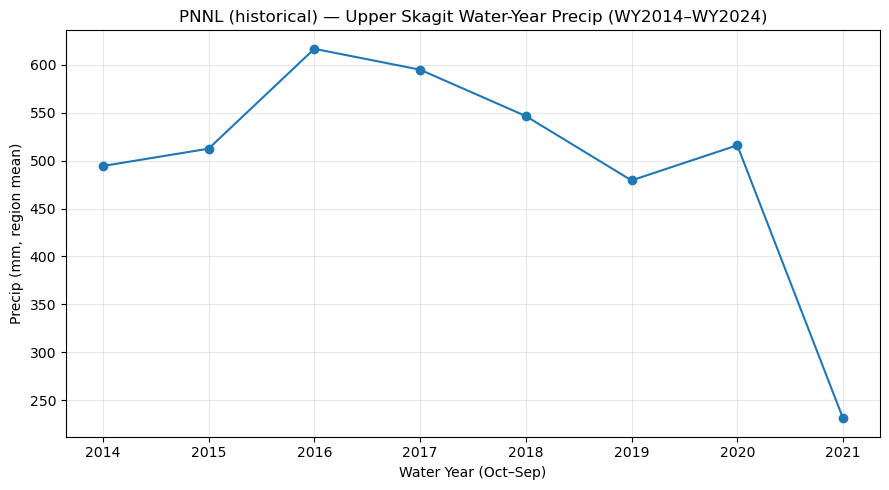

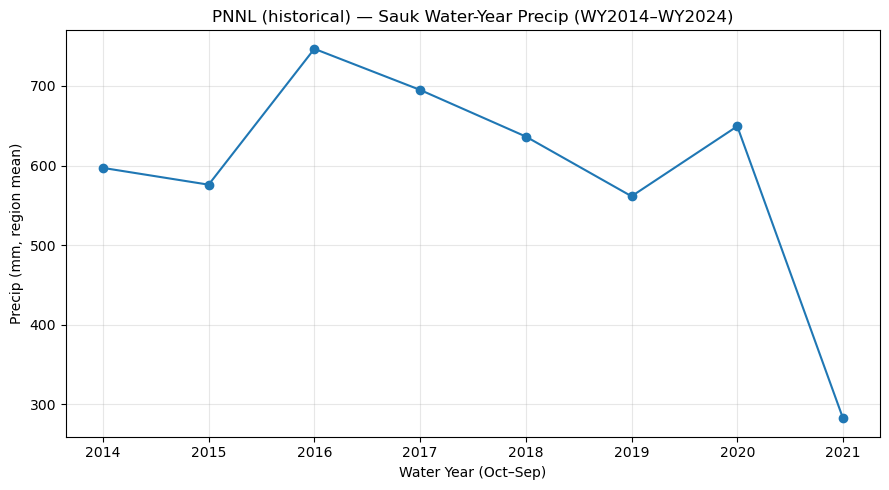

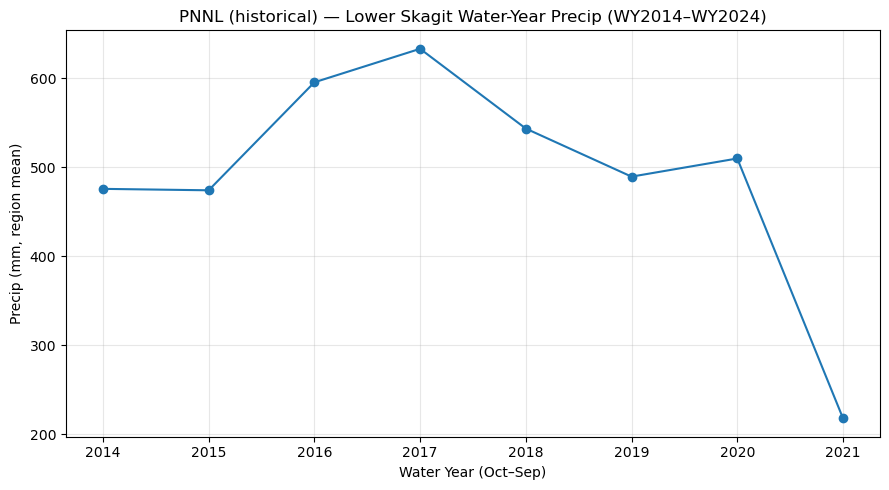

In [1]:
# ============================
# PNNL (historical) — WY precip for 3 regions (SAFE streaming, no kernel crash)
# - builds region mask from geo_em grid
# - reads PNNL PREC_ACC_NC NetCDFs file-by-file (no open_mfdataset)
# - de-accumulates across file boundaries (carry last cumulative)
# - computes WY totals as region-mean precip (mm)
# - plots 3 separate region time series
# ============================

from pathlib import Path
from glob import glob
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

import geopandas as gpd
import regionmask

# -------- Config --------
BASE = Path("/data0/balaji24/data")
PNNL_HIST = BASE / "PNNL" / "historical"

PNNL_GRID_FILE = Path("/data0/balaji24/data/PNNL/SERDP6km.geo_em.d01.nc")

BOUNDARY_GEO = Path("../data/GIS/SkagitBoundary.json")
HUC8_GEO     = Path("../data/GIS/SkagitSubBasin_HUC8.geojson")

YEAR_MIN, YEAR_MAX = 2014, 2024
REGION_NAMES = ["Upper Skagit", "Sauk", "Lower Skagit"]

def wy_start(wy: int) -> pd.Timestamp:
    return pd.Timestamp(wy - 1, 10, 1)

def wy_end(wy: int) -> pd.Timestamp:
    return pd.Timestamp(wy, 9, 30, 23, 59, 59)

def _to_2d(arr: xr.DataArray) -> xr.DataArray:
    if "time" in arr.dims:
        arr = arr.isel(time=0)
    for d in list(arr.dims):
        if arr.sizes.get(d, 0) == 1:
            arr = arr.isel({d: 0})
    while arr.ndim > 2:
        extra = [d for d in arr.dims if d not in ("x","y","lon","lat","west_east","south_north")]
        if not extra:
            break
        arr = arr.isel({extra[0]: 0})
    return arr

def find_grid_lat_lon(ds):
    lat_candidates = ["XLAT", "XLAT_M", "lat", "latitude"]
    lon_candidates = ["XLONG", "XLONG_M", "lon", "longitude"]
    lat_name = next((n for n in lat_candidates if n in ds.variables), None)
    lon_name = next((n for n in lon_candidates if n in ds.variables), None)
    return lat_name, lon_name

def ensure_time_sorted_unique(da: xr.DataArray) -> xr.DataArray:
    if "time" not in da.dims:
        return da
    da = da.sortby("time")
    # drop duplicate timestamps (cheap)
    try:
        t = da["time"].values
        _, idx = np.unique(t, return_index=True)
        da = da.isel(time=np.sort(idx))
    except Exception:
        pass
    return da

# -------- Load / build 3-region polygons clipped to Skagit --------
skagit = gpd.read_file(BOUNDARY_GEO).to_crs("EPSG:4326")
huc8   = gpd.read_file(HUC8_GEO).to_crs("EPSG:4326")

huc8_3 = huc8[huc8["Name"].isin(REGION_NAMES)].copy()
if huc8_3.empty:
    raise ValueError(f"No matching HUC8 regions found for {REGION_NAMES}. Check Name field in {HUC8_GEO}")

huc8_3 = gpd.overlay(huc8_3, skagit, how="intersection")
huc8_3 = huc8_3[["Name", "geometry"]].reset_index(drop=True)
huc8_3["Name"] = pd.Categorical(huc8_3["Name"], categories=REGION_NAMES, ordered=True)
huc8_3 = huc8_3.sort_values("Name").reset_index(drop=True)

# -------- Build regionmask on PNNL grid (geo_em) --------
grid = xr.open_dataset(PNNL_GRID_FILE, engine="netcdf4")
lat_name, lon_name = find_grid_lat_lon(grid)
if not (lat_name and lon_name):
    grid.close()
    raise ValueError(f"[GRID] Could not find XLAT/XLONG in {PNNL_GRID_FILE}. Vars: {list(grid.variables)[:50]} ...")

lat2d = _to_2d(grid[lat_name])
lon2d = _to_2d(grid[lon_name])
grid.close()

regs = regionmask.Regions(
    outlines=list(huc8_3.geometry.values),
    names=list(huc8_3["Name"].astype(str).values),
    numbers=list(range(len(huc8_3))),
    name="Skagit_3HUC8",
)

rid = regs.mask(lon2d, lat2d)  # 2D region id grid
print("[PNNL] Built region mask:", regs.names, "| shape:", tuple(rid.shape))

# Build boolean masks as DataArrays (same dims as rid)
masks = {r: (rid == i) for i, r in enumerate(REGION_NAMES)}

# -------- Locate a representative precip file to learn dim names --------
probe_files = sorted(glob(str(PNNL_HIST / "*" / "*PREC_ACC_NC*.nc")))
if not probe_files:
    raise FileNotFoundError(f"No PREC_ACC_NC files found under {PNNL_HIST}")

# -------- Main WY loop (file-by-file streaming) --------
rows = []

for wy in range(YEAR_MIN, YEAR_MAX + 1):
    t0, t1 = wy_start(wy), wy_end(wy)

    # Collect files from (wy-1) and (wy), then sort
    files = []
    for yy in [wy - 1, wy]:
        files += sorted(glob(str(PNNL_HIST / f"{yy}" / "*PREC_ACC_NC*.nc")))
    files = sorted(files)

    if not files:
        print(f"[PNNL] WY{wy}: no files -> skip")
        continue

    # Stream totals as scalars per region
    region_totals = {r: 0.0 for r in REGION_NAMES}
    prev_last = None  # last cumulative value from previous file (2D field)
    prev_last_time = None

    for fp in files:
        ds = xr.open_dataset(fp, engine="netcdf4", chunks={"time": 24 * 7})  # 1-week chunks

        if "PREC_ACC_NC" not in ds:
            ds.close()
            continue

        da = ensure_time_sorted_unique(ds["PREC_ACC_NC"])

        # slice to this WY window
        da = da.sel(time=slice(t0, t1))
        if da.sizes.get("time", 0) == 0:
            ds.close()
            continue

        # Align mask dims to da spatial dims
        # da is (time, Y, X) with some names; rid has its own dim names from geo_em (likely south_north/west_east)
        # We'll rename rid/masks dims to match da's spatial dims by position.
        spatial_dims = [d for d in da.dims if d != "time"]
        if len(spatial_dims) != 2:
            ds.close()
            raise ValueError(f"[PNNL] Unexpected PREC_ACC_NC dims: {da.dims}")

        rid_aligned = rid
        if list(rid_aligned.dims) != spatial_dims:
            rid_aligned = rid_aligned.rename({rid_aligned.dims[0]: spatial_dims[0], rid_aligned.dims[1]: spatial_dims[1]})
        masks_aligned = {r: masks[r].rename({masks[r].dims[0]: spatial_dims[0], masks[r].dims[1]: spatial_dims[1]})
                         if list(masks[r].dims) != spatial_dims else masks[r]
                         for r in REGION_NAMES}

        # --- de-accumulate WITH file-boundary carry ---
        da0 = da.isel(time=0)
        if prev_last is None:
            first_inc = da0 * 0.0
        else:
            # if there is a gap, this still gives correct increment for first step
            first_inc = (da0 - prev_last).clip(min=0)

        dif = da.diff("time", label="upper").clip(min=0)
        # prepend first_inc at first timestamp so total time length matches da
        inc = xr.concat([first_inc.expand_dims(time=[da["time"].values[0]]), dif], dim="time")

        # update carry for next file (last cumulative field)
        prev_last = da.isel(time=-1)
        prev_last_time = pd.Timestamp(da["time"].values[-1])

        # --- reduce to scalar per region for THIS file, then accumulate ---
        # mean over region cells -> time series -> sum over time -> scalar
        for r in REGION_NAMES:
            scalar = inc.where(masks_aligned[r]).mean(spatial_dims, skipna=True).sum("time", skipna=True)
            region_totals[r] += float(scalar.compute().values)

        ds.close()

    # Save WY totals
    msg = ", ".join([f"{r}={region_totals[r]:.1f}" for r in REGION_NAMES])
    print(f"[PNNL] WY{wy}: {msg}")

    for r in REGION_NAMES:
        if np.isfinite(region_totals[r]):
            rows.append({"dataset": "PNNL (historical)", "region": r, "year": wy, "mm": region_totals[r]})

df_pnnl = pd.DataFrame(rows).sort_values(["region", "year"]).reset_index(drop=True)
display(df_pnnl)

# -------- Plot (one figure per region) --------
for region in REGION_NAMES:
    sub = df_pnnl[df_pnnl["region"] == region]
    plt.figure(figsize=(9, 5))
    if sub.empty:
        plt.title(f"PNNL (historical) — {region} (no data)")
        plt.grid(True, alpha=0.3)
        plt.show()
        continue

    plt.plot(sub["year"], sub["mm"], marker="o")
    plt.title(f"PNNL (historical) — {region} Water-Year Precip (WY{YEAR_MIN}–WY{YEAR_MAX})")
    plt.xlabel("Water Year (Oct–Sep)")
    plt.ylabel("Precip (mm, region mean)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

[Coverage] Skagit basin pixels on PNNL grid: 228
[Coverage] Upper Skagit: pixels=     147  frac_of_skagit=  0.645
[Coverage] Sauk        : pixels=      55  frac_of_skagit=  0.241
[Coverage] Lower Skagit: pixels=      25  frac_of_skagit=  0.110
[Coverage] Union(3 regions): pixels=     227  frac_of_skagit=  0.996
[Coverage] Skagit pixels NOT covered by union:        1  frac_missing=  0.004
[Coverage] Union pixels OUTSIDE Skagit:        0  frac_outside_union=  0.000


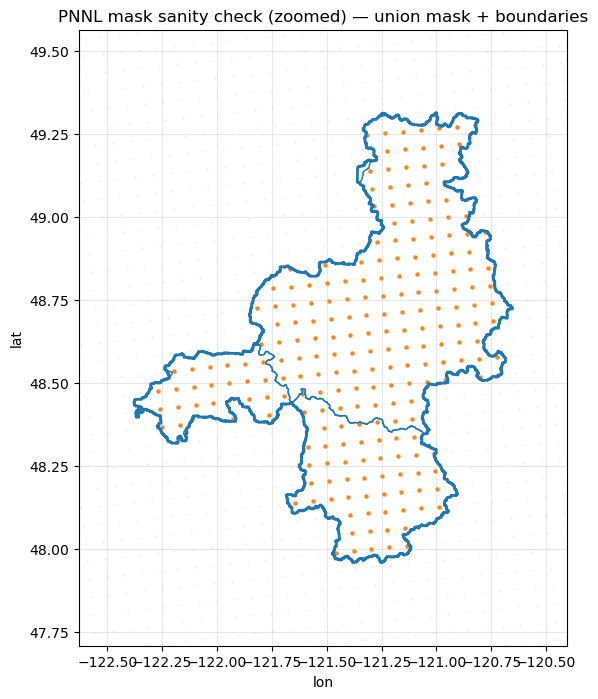

In [2]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from pathlib import Path

import geopandas as gpd
import regionmask

# ---------------- Paths ----------------
BASE = Path("/data0/balaji24/data")
BOUNDARY_GEO = Path("../data/GIS/SkagitBoundary.json")
HUC8_GEO     = Path("../data/GIS/SkagitSubBasin_HUC8.geojson")

PNNL_GRID_FILE = BASE / "PNNL" / "SERDP6km.geo_em.d01.nc"

REGION_NAMES = ["Upper Skagit", "Sauk", "Lower Skagit"]

# ---------------- Helpers ----------------
def _to_2d(arr):
    if "time" in arr.dims:
        arr = arr.isel(time=0)
    for d in list(arr.dims):
        if arr.sizes[d] == 1:
            arr = arr.isel({d: 0})
    while arr.ndim > 2:
        extra = [d for d in arr.dims if d not in ("x","y","lon","lat")]
        if not extra:
            break
        arr = arr.isel({extra[0]: 0})
    return arr

def find_grid_lat_lon(ds):
    lat_candidates = ["XLAT", "XLAT_M", "lat", "latitude"]
    lon_candidates = ["XLONG", "XLONG_M", "lon", "longitude"]
    lat_name = next((n for n in lat_candidates if n in ds.variables), None)
    lon_name = next((n for n in lon_candidates if n in ds.variables), None)
    return lat_name, lon_name

# ---------------- Load polygons ----------------
skagit = gpd.read_file(BOUNDARY_GEO).to_crs("EPSG:4326")
huc8   = gpd.read_file(HUC8_GEO).to_crs("EPSG:4326")

huc8_3 = huc8[huc8["Name"].isin(REGION_NAMES)].copy()
if huc8_3.empty:
    raise ValueError(f"No HUC8 polygons matched {REGION_NAMES}. Check the 'Name' field.")

# clip regions to skagit boundary
huc8_3 = gpd.overlay(huc8_3, skagit, how="intersection")
regions_gdf = huc8_3[["Name", "geometry"]].reset_index(drop=True)

# ensure ordering
regions_gdf["Name"] = pd.Categorical(regions_gdf["Name"], categories=REGION_NAMES, ordered=True)
regions_gdf = regions_gdf.sort_values("Name").reset_index(drop=True)

# ---------------- Load PNNL geo grid ----------------
if not PNNL_GRID_FILE.exists():
    raise FileNotFoundError(f"Missing PNNL grid file: {PNNL_GRID_FILE}")

grid = xr.open_dataset(PNNL_GRID_FILE, engine="netcdf4")
lat_name, lon_name = find_grid_lat_lon(grid)
if not (lat_name and lon_name):
    grid.close()
    raise ValueError(f"Could not find XLAT/XLONG in {PNNL_GRID_FILE}. Vars: {list(grid.variables)[:50]}")

lat2d = _to_2d(grid[lat_name])
lon2d = _to_2d(grid[lon_name])
grid.close()

# ---------------- Build region masks ----------------
regs3 = regionmask.Regions(
    outlines=list(regions_gdf.geometry.values),
    names=list(regions_gdf["Name"].astype(str).values),
    numbers=list(range(len(regions_gdf))),
    name="Skagit_3HUC8",
)
rid3 = regs3.mask(lon2d, lat2d)  # 0/1/2, NaN outside all 3 regions

# Build a "Skagit basin" mask too (not just 3 HUC8 regions)
# This uses the same PNNL lon/lat grid and the Skagit boundary polygon
regs_skagit = regionmask.Regions(
    outlines=[skagit.geometry.iloc[0]],
    names=["Skagit"],
    numbers=[0],
    name="SkagitBoundary",
)
rid_sk = regs_skagit.mask(lon2d, lat2d)
mask_skagit = (rid_sk == 0)

masks3 = {name: (rid3 == i) for i, name in enumerate(REGION_NAMES)}
mask_union = np.zeros(mask_skagit.shape, dtype=bool)
for m in masks3.values():
    mask_union |= np.asarray(m.fillna(False))

# ---------------- Numeric coverage checks ----------------
sk_pix = int(np.asarray(mask_skagit).sum())
union_pix = int(mask_union.sum())
missing_pix = int((np.asarray(mask_skagit) & (~mask_union)).sum())
outside_pix = int((mask_union & (~np.asarray(mask_skagit))).sum())

print(f"[Coverage] Skagit basin pixels on PNNL grid: {sk_pix}")
for r in REGION_NAMES:
    rp = int(np.asarray(masks3[r].fillna(False)).sum())
    frac = rp / sk_pix if sk_pix else np.nan
    print(f"[Coverage] {r:12s}: pixels={rp:8d}  frac_of_skagit={frac:7.3f}")
print(f"[Coverage] Union(3 regions): pixels={union_pix:8d}  frac_of_skagit={union_pix/sk_pix:7.3f}")
print(f"[Coverage] Skagit pixels NOT covered by union: {missing_pix:8d}  frac_missing={missing_pix/sk_pix:7.3f}")
print(f"[Coverage] Union pixels OUTSIDE Skagit: {outside_pix:8d}  frac_outside_union={(outside_pix/max(union_pix,1)):7.3f}")

# ---------------- Zoomed plot around Skagit ----------------
# Compute a tight bounding box from the Skagit polygon
minx, miny, maxx, maxy = skagit.total_bounds
pad = 0.25
x0, x1 = minx - pad, maxx + pad
y0, y1 = miny - pad, maxy + pad

plt.figure(figsize=(8, 8))
# plot rid3 as an image by scatter (safe even if curvilinear)
# only plot points near Skagit bbox to reduce draw time
lonv = lon2d.values
latv = lat2d.values
sel = (lonv >= x0) & (lonv <= x1) & (latv >= y0) & (latv <= y1)

# show union mask points
plt.scatter(lonv[sel], latv[sel], s=1, alpha=0.05)
plt.scatter(lonv[sel & mask_union], latv[sel & mask_union], s=5, alpha=0.9)

# overlay polygon boundaries
skagit.boundary.plot(ax=plt.gca(), linewidth=2)
regions_gdf.boundary.plot(ax=plt.gca(), linewidth=1)

plt.xlim(x0, x1)
plt.ylim(y0, y1)
plt.xlabel("lon")
plt.ylabel("lat")
plt.title("PNNL mask sanity check (zoomed) — union mask + boundaries")
plt.grid(True, alpha=0.3)
plt.show()


# PNNL Sub Basin

In [ ]:
# ============================
# PNNL (historical) — MET SEASON precip by 3 Skagit sub-basins
#   p = dsp[PREC_ACC_NC].sel(time=season_window)
#   P = p.sum("time")
#   region_mean = P[mask].mean()
#
# ============================

import json
from pathlib import Path
from glob import glob
import numpy as np
import pandas as pd
import xarray as xr

# ---------------- Config ----------------
BASE = Path("/data0/balaji24/data")
BOUNDARY_GEO = Path("../data/GIS/SkagitBoundary.json")
HUC8_GEO     = Path("../data/GIS/SkagitSubBasin_HUC8.geojson")

PNNL_HIST      = BASE / "PNNL" / "historical"
PNNL_GRID_FILE = BASE / "PNNL" / "SERDP6km.geo_em.d01.nc"   # lat/lon grid file

YEAR_MIN, YEAR_MAX = 2014, 2024  # season-year labels (DJF labeled by ending year)
REGION_NAMES = ["Upper Skagit", "Sauk", "Lower Skagit"]

OUT = BASE / "derived"
OUT.mkdir(parents=True, exist_ok=True)
CSV_OUT = OUT / f"pnnl_met_season_precip_3regions_{YEAR_MIN}_{YEAR_MAX}.csv"

# ---------------- Seasons ----------------
SEASONS = {
    "DJF": [12, 1, 2],
    "MAM": [3, 4, 5],
    "JJA": [6, 7, 8],
    "SON": [9, 10, 11],
}

def month_end(y, m):
    return (pd.Timestamp(y, m, 1) + pd.offsets.MonthEnd(0)).strftime("%Y-%m-%d")

def season_time_window(year, season_label):
    """Return ISO start/end (inclusive). DJF labeled by ending year."""
    if season_label == "DJF":
        start = pd.Timestamp(year - 1, 12, 1).strftime("%Y-%m-%d")
        end   = month_end(year, 2)
        return start, end
    if season_label == "MAM":
        return f"{year}-03-01", month_end(year, 5)
    if season_label == "JJA":
        return f"{year}-06-01", month_end(year, 8)
    if season_label == "SON":
        return f"{year}-09-01", month_end(year, 11)
    raise ValueError(season_label)

def ensure_time_sorted_unique(da):
    if "time" not in da.dims:
        return da
    da = da.sortby("time")
    try:
        t = np.asarray(da["time"].values)
        _, idx = np.unique(t, return_index=True)
        da = da.isel(time=np.sort(idx))
    except Exception:
        pass
    return da

def _to_2d(arr):
    """Reduce XLAT/XLONG to 2D."""
    if "time" in arr.dims:
        arr = arr.isel(time=0)
    for d in list(arr.dims):
        if arr.sizes[d] == 1:
            arr = arr.isel({d: 0})
    while arr.ndim > 2:
        # drop extra dims until 2D
        arr = arr.isel({arr.dims[0]: 0})
    return arr

def find_grid_lat_lon(ds):
    lat_candidates = ["XLAT", "XLAT_M", "lat", "latitude"]
    lon_candidates = ["XLONG", "XLONG_M", "lon", "longitude"]
    lat_name = next((n for n in lat_candidates if n in ds.variables), None)
    lon_name = next((n for n in lon_candidates if n in ds.variables), None)
    return lat_name, lon_name

def load_regions_gdf():
    import geopandas as gpd
    skagit = gpd.read_file(BOUNDARY_GEO).to_crs("EPSG:4326")
    huc8   = gpd.read_file(HUC8_GEO).to_crs("EPSG:4326")

    huc8_3 = huc8[huc8["Name"].isin(REGION_NAMES)].copy()
    if huc8_3.empty:
        raise ValueError(f"No matching HUC8 regions found for {REGION_NAMES}. Check 'Name' field.")

    # clip to Skagit boundary
    huc8_3 = gpd.overlay(huc8_3, skagit, how="intersection")
    regions_gdf = huc8_3[["Name", "geometry"]].reset_index(drop=True)

    # preserve desired order
    regions_gdf["Name"] = pd.Categorical(regions_gdf["Name"], categories=REGION_NAMES, ordered=True)
    regions_gdf = regions_gdf.sort_values("Name").reset_index(drop=True)
    return regions_gdf

def build_region_masks_on_pnnl_grid(regions_gdf):
    import regionmask

    grid = xr.open_dataset(PNNL_GRID_FILE, engine="netcdf4")
    lat_name, lon_name = find_grid_lat_lon(grid)
    if not (lat_name and lon_name):
        grid.close()
        raise ValueError(f"Could not find lat/lon in {PNNL_GRID_FILE}. Vars: {list(grid.variables)[:50]}")

    lat2d = _to_2d(grid[lat_name])
    lon2d = _to_2d(grid[lon_name])
    grid.close()

    regs = regionmask.Regions(
        outlines=list(regions_gdf.geometry.values),
        names=list(regions_gdf["Name"].astype(str).values),
        numbers=list(range(len(regions_gdf))),
        name="Skagit_3HUC8",
    )

    rid = regs.mask(lon2d, lat2d)  # 2D ids, same dims as lat2d/lon2d
    masks = {name: (rid == i) for i, name in enumerate(REGION_NAMES)}

    print(f"[PNNL] Built region-id mask on grid shape={tuple(rid.shape)}")
    for r in REGION_NAMES:
        print(f"  - {r}: pixels={int(masks[r].sum().values)}")

    return masks

def expected_months_for_season(season_label):
    return set(SEASONS[season_label])

def months_present_in_selection(time_values):
    # normalized to unique months only
    t = pd.to_datetime(time_values)
    return set(pd.Index(t.month).unique().tolist())

def years_needed_for_season(season_label, yr):
    # which year-folders we need to open for this season window
    if season_label == "DJF":
        return {yr - 1, yr}
    return {yr}

# ---------------- Main ----------------
if not (PNNL_HIST.exists() and PNNL_GRID_FILE.exists()):
    raise FileNotFoundError(f"Missing PNNL folders/files: {PNNL_HIST} or {PNNL_GRID_FILE}")

regions_gdf = load_regions_gdf()
masks3 = build_region_masks_on_pnnl_grid(regions_gdf)

rows = []
print("[PNNL] Starting regional seasonal ingest...")

for s in SEASONS.keys():
    need_months = expected_months_for_season(s)

    for yr in range(YEAR_MIN, YEAR_MAX + 1):
        t0, t1 = season_time_window(yr, s)

        # collect files from required year folders
        files = []
        for yy in sorted(years_needed_for_season(s, yr)):
            files += sorted(glob(str(PNNL_HIST / f"{yy}" / "*PREC_ACC_NC*.nc")))
        files = sorted(files)

        if not files:
            continue

        # open lazily, minimal memory; preprocess keeps only PREC_ACC_NC if present
        def _preprocess(ds):
            keep = [v for v in ds.data_vars if "PREC_ACC_NC" in v]
            if keep:
                return ds[keep]
            return ds

        dsp = xr.open_mfdataset(
            files,
            combine="by_coords",
            engine="netcdf4",
            parallel=False,
            preprocess=_preprocess,
            chunks={"time": 24 * 7},  # weekly chunks
        )

        v = next((vv for vv in dsp.data_vars if "PREC_ACC_NC" in vv), None)
        if v is None:
            dsp.close()
            continue

        p = ensure_time_sorted_unique(dsp[v]).sel(time=slice(t0, t1))
        if p.sizes.get("time", 0) == 0:
            dsp.close()
            continue

        # --- month completeness check  ---
        seen_months = months_present_in_selection(p["time"].values)
        missing_months = sorted(list(need_months - set(seen_months)))
        if missing_months:
            print(f"[PNNL] SKIP {s} {yr}: missing months {missing_months} (seen={sorted(list(seen_months))})")
            dsp.close()
            continue

        # Sum over time FIRST (produces 2D field), then mean over mask pixels.
        P = p.sum(dim="time", skipna=True)

        spatial_dims = [d for d in P.dims if d != "time"]
        if len(spatial_dims) != 2:
            dsp.close()
            raise ValueError(f"[PNNL] Unexpected spatial dims for {v}: {P.dims}")

        region_totals = {}
        for r in REGION_NAMES:
            # IMPORTANT: keep mask as DataArray (same dims) to avoid huge broadcasting
            mr = masks3[r]
            if set(mr.dims) != set(spatial_dims):
                # try to rename by position if dims differ (e.g., ('south_north','west_east') vs ('y','x'))
                mr = mr.rename({mr.dims[0]: spatial_dims[0], mr.dims[1]: spatial_dims[1]})

            # mean over region pixels -> scalar
            val = P.where(mr).mean(dim=spatial_dims, skipna=True).compute()
            region_totals[r] = float(val.values)

            rows.append({
                "dataset": "PNNL (historical)",
                "region": r,
                "season": s,
                "year": int(yr),
                "mm": region_totals[r],
            })

        print(f"[PNNL] {s} {yr}: " + ", ".join([f"{r}={region_totals[r]:.1f}" for r in REGION_NAMES]))
        dsp.close()

print("[PNNL] Done.")

df = pd.DataFrame(rows).sort_values(["region","season","year"]).reset_index(drop=True)
print(df.head(30))
df.to_csv(CSV_OUT, index=False)
print("Saved CSV →", CSV_OUT)


[PNNL] Built region-id mask on grid shape=(450, 450)
  - Upper Skagit: pixels=147
  - Sauk: pixels=55
  - Lower Skagit: pixels=25
[PNNL] Starting regional seasonal ingest...
[PNNL] DJF 2014: Upper Skagit=777.9, Sauk=861.7, Lower Skagit=521.2
[PNNL] DJF 2015: Upper Skagit=865.0, Sauk=979.1, Lower Skagit=694.9
[PNNL] DJF 2016: Upper Skagit=1219.2, Sauk=1383.1, Lower Skagit=909.0
[PNNL] DJF 2017: Upper Skagit=783.2, Sauk=847.2, Lower Skagit=642.8
[PNNL] DJF 2018: Upper Skagit=923.1, Sauk=1042.5, Lower Skagit=744.3
[PNNL] DJF 2019: Upper Skagit=887.8, Sauk=983.7, Lower Skagit=729.4
[PNNL] DJF 2020: Upper Skagit=1367.1, Sauk=1561.8, Lower Skagit=1046.6
[PNNL] SKIP DJF 2021: missing months [1, 2] (seen=[12])
[PNNL] MAM 2014: Upper Skagit=726.5, Sauk=895.2, Lower Skagit=618.9
[PNNL] MAM 2015: Upper Skagit=342.2, Sauk=372.9, Lower Skagit=274.5
[PNNL] MAM 2016: Upper Skagit=425.7, Sauk=529.9, Lower Skagit=347.5
[PNNL] MAM 2017: Upper Skagit=737.9, Sauk=784.4, Lower Skagit=612.9
[PNNL] MAM 2018: